# Digital Marketing ROI Prediction

## 1. Business problem and project objective

Digital-marketing teams invest across multiple campaign channels and customer segments, but the revenue generated by a campaign varies with its budget, reach, engagement, conversion performance, order value, and duration.

The objective of this project is to develop a regression model that can predict **`Monthly_Revenue_Generated`** from the available campaign characteristics. A useful model can support budget planning, campaign comparison, and revenue forecasting.

This first part of the notebook focuses only on loading, understanding, and validating the dataset. It does **not** perform feature engineering, split the data, or train a model.

## 2. Importing required libraries

The following libraries support data handling, visualisation, statistical analysis, future regression modelling, diagnostics, and model persistence. Importing modelling tools here does not fit or train a model.

In [1]:
# Import libraries required for exploration, statistical analysis, and later modelling.
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.api as sm
from scipy import stats
import joblib

# Set reproducible defaults for later analysis without training a model here.
RANDOM_SEED = 20260914
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid")

## 3. Loading `data.csv`

The dataset is loaded from the same directory as this notebook. The file-existence check provides a clear error if the notebook is run from the wrong working directory.

In [2]:
# Locate and load the CSV file while preserving its original column names.
DATA_PATH = Path("data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. "
        "Place data.csv in the notebook's working directory."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH.name} successfully.")

Loaded data.csv successfully.


## 4. Initial dataset inspection

The following cells verify the dataset dimensions and schema, display a small sample, and inspect the inferred pandas data types.

In [3]:
# Display the number of rows and columns and list every exact column name.
print("Dataframe shape:", df.shape)
print("\nExact column names:")
print(df.columns.tolist())

Dataframe shape: (2000, 11)

Exact column names:
['Campaign_ID', 'Campaign_Channel', 'Target_Segment', 'Ad_Spend', 'Impressions', 'Clicks', 'Conversion_Rate', 'Average_Order_Value', 'Campaign_Duration_Days', 'Email_Open_Rate', 'Monthly_Revenue_Generated']


In [4]:
# Display the first five records to inspect representative values.
df.head()

,Campaign_ID,Campaign_Channel,Target_Segment,Ad_Spend,Impressions,Clicks,Conversion_Rate,Average_Order_Value,Campaign_Duration_Days,Email_Open_Rate,Monthly_Revenue_Generated
0,CMP0001,Search,Existing Customers,"287,844.92",586840,19308,7.00,"3,087.02",78,31.92,"1,990,399.88"
1,CMP0002,Social Media,Existing Customers,"307,760.85",789468,14513,3.49,"2,721.39",35,23.93,"1,196,314.43"
2,CMP0003,Display,High Value,"224,049.22",862201,7610,4.31,"5,657.40",84,35.41,"1,467,163.45"
3,CMP0004,Affiliate,New Customers,"66,514.17",121216,1864,6.26,"3,708.45",17,26.88,"874,015.23"
4,CMP0005,Email,Small Business,"418,341.36",944032,25166,6.79,"6,876.28",59,44.82,"2,298,128.92"


In [5]:
# Display the data type inferred for each column.
df.dtypes.rename("Data_Type").to_frame()

,Data_Type
Campaign_ID,str
Campaign_Channel,str
Target_Segment,str
Ad_Spend,float64
Impressions,int64
Clicks,int64
Conversion_Rate,float64
Average_Order_Value,float64
Campaign_Duration_Days,int64
Email_Open_Rate,float64


## 5. Descriptive statistics

Numerical summaries show central tendency, spread, and observed ranges. Categorical summaries show non-null counts, distinct values, the most frequent category, and its frequency.

In [6]:
# Summarise all numerical columns and transpose the output for readability.
numerical_summary = df.select_dtypes(include=np.number).describe().T
numerical_summary

,count,mean,std,min,25%,50%,75%,max
Ad_Spend,"2,000.00","230,630.42","110,492.21","11,237.96","144,087.90","227,077.58","311,241.31","492,697.19"
Impressions,"2,000.00","629,357.50","381,633.45","22,973.00","332,144.25","560,248.50","859,235.25","2,000,000.00"
Clicks,"2,000.00","15,227.50","11,699.60",425.00,"6,939.75","12,706.50","20,646.50","128,297.00"
Conversion_Rate,"2,000.00",4.62,2.33,0.50,2.86,4.63,6.26,13.55
Average_Order_Value,"2,000.00","4,026.02","2,201.86",801.04,"2,373.78","3,424.22","5,273.17","10,000.00"
Campaign_Duration_Days,"2,000.00",49.13,24.03,7.00,28.00,50.00,70.00,90.00
Email_Open_Rate,"2,000.00",32.89,10.52,5.82,25.42,32.29,39.92,65.00
Monthly_Revenue_Generated,"2,000.00","1,394,295.06","409,254.53","228,648.31","1,109,270.52","1,375,516.33","1,658,833.21","3,587,856.07"


In [7]:
# Summarise identifier and categorical text columns.
categorical_summary = df.select_dtypes(include=["object", "string"]).describe().T
categorical_summary

,count,unique,top,freq
Campaign_ID,2000,2000,CMP0001,1
Campaign_Channel,2000,5,Social Media,491
Target_Segment,2000,5,New Customers,516


## 6. Missing-value assessment

Both counts and percentages are calculated. Percentages make missingness comparable across datasets of different sizes.

In [8]:
# Calculate missing-value counts and percentages for every column.
missing_counts = df.isna().sum()
missing_percentages = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame(
    {
        "Missing_Count": missing_counts,
        "Missing_Percentage": missing_percentages,
    }
)
missing_summary

,Missing_Count,Missing_Percentage
Campaign_ID,0,0.00
Campaign_Channel,0,0.00
Target_Segment,0,0.00
Ad_Spend,0,0.00
Impressions,0,0.00
Clicks,0,0.00
Conversion_Rate,0,0.00
Average_Order_Value,0,0.00
Campaign_Duration_Days,0,0.00
Email_Open_Rate,0,0.00


## 7. Exact duplicate-row check

An exact duplicate has the same value in every column. The first occurrence is retained conceptually, while subsequent identical rows are counted as duplicates.

In [9]:
# Count exact duplicate rows and display them only if any are present.
exact_duplicate_count = int(df.duplicated().sum())
exact_duplicate_mask = df.duplicated(keep=False)

print("Exact duplicate row count:", exact_duplicate_count)

if exact_duplicate_mask.any():
    display(df.loc[exact_duplicate_mask].sort_values("Campaign_ID"))
else:
    print("No exact duplicate rows were detected.")

Exact duplicate row count: 0
No exact duplicate rows were detected.


## 8. `Campaign_ID` uniqueness check

`Campaign_ID` is an identifier and should uniquely identify one record. This check reports both the Boolean result and the number of repeated identifier values.

In [10]:
# Verify identifier uniqueness and inspect repeated IDs if they exist.
campaign_id_is_unique = df["Campaign_ID"].is_unique
campaign_id_duplicate_count = int(df["Campaign_ID"].duplicated().sum())

print("Campaign_ID is unique:", campaign_id_is_unique)
print("Repeated Campaign_ID count:", campaign_id_duplicate_count)

if not campaign_id_is_unique:
    display(
        df.loc[df["Campaign_ID"].duplicated(keep=False)]
        .sort_values("Campaign_ID")
    )

Campaign_ID is unique: True
Repeated Campaign_ID count: 0


## 9. Category-name consistency checks

The expected category lists are compared with the raw values in the dataset. The checks detect leading or trailing whitespace, repeated internal spaces, capitalization-only variations, unexpected spellings, multiple raw labels that normalize to the same category, and expected categories that are absent.

These checks are read-only: no category value is changed in this section.

In [11]:
# Define the exact allowed categories without altering the source dataframe.
expected_categories = {
    "Campaign_Channel": {
        "Search",
        "Social Media",
        "Email",
        "Display",
        "Affiliate",
    },
    "Target_Segment": {
        "New Customers",
        "Existing Customers",
        "High Value",
        "Price Sensitive",
        "Small Business",
    },
}


def normalize_category(value):
    # Normalize spacing and capitalization only for comparison purposes.
    return re.sub(r"\s+", " ", str(value).strip()).casefold()


category_quality_rows = []

for column, expected_values in expected_categories.items():
    non_missing = df[column].dropna().astype(str)
    observed_values = sorted(non_missing.unique().tolist())
    expected_by_normalized = {
        normalize_category(value): value for value in expected_values
    }

    leading_or_trailing = non_missing.str.strip().ne(non_missing)
    repeated_internal_space = non_missing.str.contains(r"\s{2,}", regex=True)

    capitalization_or_spacing_values = []
    unexpected_spelling_values = []

    for raw_value in observed_values:
        normalized_value = normalize_category(raw_value)
        if raw_value in expected_values:
            continue
        if normalized_value in expected_by_normalized:
            capitalization_or_spacing_values.append(raw_value)
        else:
            unexpected_spelling_values.append(raw_value)

    normalized_groups = {}
    for raw_value in observed_values:
        normalized_groups.setdefault(normalize_category(raw_value), []).append(raw_value)
    inconsistent_variant_groups = [
        values for values in normalized_groups.values() if len(values) > 1
    ]

    missing_expected_values = sorted(expected_values - set(observed_values))

    checks = [
        (
            "Leading or trailing whitespace",
            int(leading_or_trailing.sum()),
            sorted(non_missing[leading_or_trailing].unique().tolist()),
        ),
        (
            "Repeated internal whitespace",
            int(repeated_internal_space.sum()),
            sorted(non_missing[repeated_internal_space].unique().tolist()),
        ),
        (
            "Capitalization or spacing mismatch",
            int(non_missing.isin(capitalization_or_spacing_values).sum()),
            capitalization_or_spacing_values,
        ),
        (
            "Unexpected spelling or category",
            int(non_missing.isin(unexpected_spelling_values).sum()),
            unexpected_spelling_values,
        ),
        (
            "Inconsistent normalized variants",
            len(inconsistent_variant_groups),
            inconsistent_variant_groups,
        ),
        (
            "Expected categories absent",
            len(missing_expected_values),
            missing_expected_values,
        ),
    ]

    for check_name, issue_count, details in checks:
        category_quality_rows.append(
            {
                "Column": column,
                "Check": check_name,
                "Issue_Count": issue_count,
                "Details": details if details else "None",
            }
        )

    print(f"{column} observed values: {observed_values}")

category_quality_table = pd.DataFrame(category_quality_rows)
category_quality_table

Campaign_Channel observed values: ['Affiliate', 'Display', 'Email', 'Search', 'Social Media']
Target_Segment observed values: ['Existing Customers', 'High Value', 'New Customers', 'Price Sensitive', 'Small Business']


,Column,Check,Issue_Count,Details
0,Campaign_Channel,Leading or trailing whitespace,0,None
1,Campaign_Channel,Repeated internal whitespace,0,None
2,Campaign_Channel,Capitalization or spacing mismatch,0,None
3,Campaign_Channel,Unexpected spelling or category,0,None
4,Campaign_Channel,Inconsistent normalized variants,0,None
5,Campaign_Channel,Expected categories absent,0,None
6,Target_Segment,Leading or trailing whitespace,0,None
7,Target_Segment,Repeated internal whitespace,0,None
8,Target_Segment,Capitalization or spacing mismatch,0,None
9,Target_Segment,Unexpected spelling or category,0,None


## 10. Impossible-value and logical-rule checks

The rules below identify invalid monetary values, non-positive activity counts, impossible click totals, percentages outside 0–100, non-positive campaign durations, and non-positive revenue. Missing values are handled separately and are not double-counted as logical violations.

In [12]:
# Create one Boolean violation mask for each business and logical rule.
monetary_columns = [
    "Ad_Spend",
    "Average_Order_Value",
    "Monthly_Revenue_Generated",
]
percentage_columns = [
    "Conversion_Rate",
    "Email_Open_Rate",
]

rule_masks = {}

for column in monetary_columns:
    rule_masks[f"{column} is negative"] = (
        df[column].notna() & df[column].lt(0)
    )

rule_masks["Impressions is not positive"] = (
    df["Impressions"].notna() & df["Impressions"].le(0)
)
rule_masks["Clicks is not positive"] = (
    df["Clicks"].notna() & df["Clicks"].le(0)
)
rule_masks["Clicks exceeds Impressions"] = (
    df["Clicks"].notna()
    & df["Impressions"].notna()
    & df["Clicks"].gt(df["Impressions"])
)

for column in percentage_columns:
    rule_masks[f"{column} is outside 0-100"] = (
        df[column].notna()
        & ~df[column].between(0, 100, inclusive="both")
    )

rule_masks["Campaign_Duration_Days is not positive"] = (
    df["Campaign_Duration_Days"].notna()
    & df["Campaign_Duration_Days"].le(0)
)
rule_masks["Monthly_Revenue_Generated is not positive"] = (
    df["Monthly_Revenue_Generated"].notna()
    & df["Monthly_Revenue_Generated"].le(0)
)

logical_quality_rows = []
for rule_name, violation_mask in rule_masks.items():
    affected_ids = df.loc[violation_mask, "Campaign_ID"].head(5).tolist()
    logical_quality_rows.append(
        {
            "Rule": rule_name,
            "Issue_Count": int(violation_mask.sum()),
            "Example_Campaign_IDs": affected_ids if affected_ids else "None",
        }
    )

logical_quality_table = pd.DataFrame(logical_quality_rows)
logical_quality_table

,Rule,Issue_Count,Example_Campaign_IDs
0,Ad_Spend is negative,0,None
1,Average_Order_Value is negative,0,None
2,Monthly_Revenue_Generated is negative,0,None
3,Impressions is not positive,0,None
4,Clicks is not positive,0,None
5,Clicks exceeds Impressions,0,None
6,Conversion_Rate is outside 0-100,0,None
7,Email_Open_Rate is outside 0-100,0,None
8,Campaign_Duration_Days is not positive,0,None
9,Monthly_Revenue_Generated is not positive,0,None


## 11. Consolidated data-quality summary

This table combines the preceding checks into one compact report. A **Pass** status means that the issue count is zero; **Review** means that one or more records or category definitions require investigation. The table reports findings without modifying or deleting any data.

In [13]:
# Combine missingness, duplicate, identifier, category, and logical checks.
quality_rows = [
    {
        "Area": "Missing values",
        "Column_or_Rule": "All columns",
        "Issue_Count": int(missing_counts.sum()),
        "Details": (
            missing_counts[missing_counts.gt(0)].to_dict()
            if missing_counts.gt(0).any()
            else "None"
        ),
    },
    {
        "Area": "Duplicates",
        "Column_or_Rule": "Exact duplicate rows",
        "Issue_Count": exact_duplicate_count,
        "Details": "None" if exact_duplicate_count == 0 else "Inspect duplicate rows above",
    },
    {
        "Area": "Identifier",
        "Column_or_Rule": "Repeated Campaign_ID values",
        "Issue_Count": campaign_id_duplicate_count,
        "Details": "None" if campaign_id_duplicate_count == 0 else "Inspect repeated IDs above",
    },
]

for row in category_quality_rows:
    quality_rows.append(
        {
            "Area": "Category consistency",
            "Column_or_Rule": f"{row['Column']}: {row['Check']}",
            "Issue_Count": int(row["Issue_Count"]),
            "Details": row["Details"],
        }
    )

for row in logical_quality_rows:
    quality_rows.append(
        {
            "Area": "Logical validity",
            "Column_or_Rule": row["Rule"],
            "Issue_Count": int(row["Issue_Count"]),
            "Details": row["Example_Campaign_IDs"],
        }
    )

data_quality_summary = pd.DataFrame(quality_rows)
data_quality_summary.insert(
    2,
    "Status",
    np.where(data_quality_summary["Issue_Count"].eq(0), "Pass", "Review"),
)

display(data_quality_summary)

total_detected_issues = int(data_quality_summary["Issue_Count"].sum())
print("Total issue instances detected:", total_detected_issues)

if total_detected_issues == 0:
    print("No data-quality issues were detected by the specified checks.")
else:
    print("Review the rows marked 'Review' before beginning model development.")

,Area,Column_or_Rule,Status,Issue_Count,Details
0,Missing values,All columns,Pass,0,None
1,Duplicates,Exact duplicate rows,Pass,0,None
2,Identifier,Repeated Campaign_ID values,Pass,0,None
3,Category consistency,Campaign_Channel: Leading or trailing whitespace,Pass,0,None
4,Category consistency,Campaign_Channel: Repeated internal whitespace,Pass,0,None
5,Category consistency,Campaign_Channel: Capitalization or spacing mi...,Pass,0,None
6,Category consistency,Campaign_Channel: Unexpected spelling or category,Pass,0,None
7,Category consistency,Campaign_Channel: Inconsistent normalized vari...,Pass,0,None
8,Category consistency,Campaign_Channel: Expected categories absent,Pass,0,None
9,Category consistency,Target_Segment: Leading or trailing whitespace,Pass,0,None


Total issue instances detected: 0
No data-quality issues were detected by the specified checks.


### End of the data-understanding and validation stage

No model has been trained. Subsequent sections can address exploratory visualisation, feature preparation, train/test splitting, regression modelling, diagnostics, evaluation, and model persistence.

# Step 3 — Data cleaning and feature identification

The initial audit found no missing values, exact duplicate rows, repeated `Campaign_ID` values, category-label inconsistencies, or impossible values. Therefore, cleaning must preserve all observations. The code below creates a deep copy, documents the decision for every potential cleaning action, and repeats the quality checks before modelling.

No observation is removed or altered without a documented reason.

In [14]:
# Preserve an untouched copy before any cleaning decision is made.
df_original = df.copy(deep=True)
df_clean = df_original.copy(deep=True)

rows_initial = len(df_clean)
cleaning_log = []


def record_cleaning_action(action, rows_before, rows_after, reason):
    # Record the row count and decision for one potential cleaning action.
    cleaning_log.append(
        {
            "Action": action,
            "Rows_Before": int(rows_before),
            "Rows_After": int(rows_after),
            "Rows_Removed": int(rows_before - rows_after),
            "Decision": reason,
        }
    )


# 1. Missing values: none were detected, so no imputation or deletion is justified.
rows_before = len(df_clean)
missing_cell_count = int(df_clean.isna().sum().sum())
record_cleaning_action(
    "Missing-value treatment",
    rows_before,
    len(df_clean),
    "No action required" if missing_cell_count == 0 else "Flag for review before treatment",
)

# 2. Exact duplicates: none were detected, so no rows are dropped.
rows_before = len(df_clean)
duplicate_row_count = int(df_clean.duplicated().sum())
record_cleaning_action(
    "Exact-duplicate treatment",
    rows_before,
    len(df_clean),
    "No action required" if duplicate_row_count == 0 else "Flagged; no automatic deletion",
)

# 3. Category labels: compare against exact allowed values without changing source labels.
expected_categories_cleaning = {
    "Campaign_Channel": {"Search", "Social Media", "Email", "Display", "Affiliate"},
    "Target_Segment": {
        "New Customers",
        "Existing Customers",
        "High Value",
        "Price Sensitive",
        "Small Business",
    },
}
rows_before = len(df_clean)
category_issue_count = 0
for column, allowed_values in expected_categories_cleaning.items():
    values = df_clean[column].dropna().astype(str)
    category_issue_count += int(values.str.strip().ne(values).sum())
    category_issue_count += int((~values.isin(allowed_values)).sum())
record_cleaning_action(
    "Category-label treatment",
    rows_before,
    len(df_clean),
    "No action required" if category_issue_count == 0 else "Flagged; labels require documented mapping",
)

# 4. Impossible values: flag any violations, but never delete valid extremes automatically.
rows_before = len(df_clean)
impossible_masks_cleaning = {
    "Negative monetary value": df_clean[
        ["Ad_Spend", "Average_Order_Value", "Monthly_Revenue_Generated"]
    ].lt(0).any(axis=1),
    "Non-positive Impressions": df_clean["Impressions"].le(0),
    "Non-positive Clicks": df_clean["Clicks"].le(0),
    "Clicks exceed Impressions": df_clean["Clicks"].gt(df_clean["Impressions"]),
    "Invalid percentage": (
        ~df_clean["Conversion_Rate"].between(0, 100)
        | ~df_clean["Email_Open_Rate"].between(0, 100)
    ),
    "Non-positive duration": df_clean["Campaign_Duration_Days"].le(0),
    "Non-positive revenue": df_clean["Monthly_Revenue_Generated"].le(0),
}
impossible_issue_count = int(
    pd.DataFrame(impossible_masks_cleaning).any(axis=1).sum()
)
record_cleaning_action(
    "Impossible-value treatment",
    rows_before,
    len(df_clean),
    "No action required" if impossible_issue_count == 0 else "Flagged; investigate before any correction",
)

cleaning_log_table = pd.DataFrame(cleaning_log)
display(cleaning_log_table)
print(f"Overall rows before cleaning: {rows_initial:,}")
print(f"Overall rows after cleaning:  {len(df_clean):,}")

,Action,Rows_Before,Rows_After,Rows_Removed,Decision
0,Missing-value treatment,2000,2000,0,No action required
1,Exact-duplicate treatment,2000,2000,0,No action required
2,Category-label treatment,2000,2000,0,No action required
3,Impossible-value treatment,2000,2000,0,No action required


Overall rows before cleaning: 2,000
Overall rows after cleaning:  2,000


## Post-cleaning quality verification

The complete set of checks is repeated on `df_clean`. This confirms that the preserved dataframe remains suitable for the modelling stages and makes the cleaning decision auditable.

In [15]:
# Re-run the requested quality checks after the documented cleaning decisions.
post_cleaning_checks = []

for column in df_clean.columns:
    post_cleaning_checks.append(
        {
            "Check": f"Missing values: {column}",
            "Issue_Count": int(df_clean[column].isna().sum()),
        }
    )

post_cleaning_checks.extend(
    [
        {"Check": "Exact duplicate rows", "Issue_Count": int(df_clean.duplicated().sum())},
        {
            "Check": "Repeated Campaign_ID values",
            "Issue_Count": int(df_clean["Campaign_ID"].duplicated().sum()),
        },
    ]
)

for column, allowed_values in expected_categories_cleaning.items():
    values = df_clean[column].dropna().astype(str)
    post_cleaning_checks.extend(
        [
            {
                "Check": f"{column}: surrounding whitespace",
                "Issue_Count": int(values.str.strip().ne(values).sum()),
            },
            {
                "Check": f"{column}: unexpected category",
                "Issue_Count": int((~values.isin(allowed_values)).sum()),
            },
        ]
    )

for rule_name, mask in impossible_masks_cleaning.items():
    post_cleaning_checks.append(
        {"Check": rule_name, "Issue_Count": int(mask.sum())}
    )

post_cleaning_quality = pd.DataFrame(post_cleaning_checks)
post_cleaning_quality["Status"] = np.where(
    post_cleaning_quality["Issue_Count"].eq(0), "Pass", "Review"
)
display(post_cleaning_quality)
print("Total post-cleaning issue instances:", int(post_cleaning_quality["Issue_Count"].sum()))

,Check,Issue_Count,Status
0,Missing values: Campaign_ID,0,Pass
1,Missing values: Campaign_Channel,0,Pass
2,Missing values: Target_Segment,0,Pass
3,Missing values: Ad_Spend,0,Pass
4,Missing values: Impressions,0,Pass
5,Missing values: Clicks,0,Pass
6,Missing values: Conversion_Rate,0,Pass
7,Missing values: Average_Order_Value,0,Pass
8,Missing values: Campaign_Duration_Days,0,Pass
9,Missing values: Email_Open_Rate,0,Pass


Total post-cleaning issue instances: 0


## Feature roles and leakage prevention

- **Target:** `Monthly_Revenue_Generated`
- **Identifier:** `Campaign_ID`
- **Categorical predictors:** `Campaign_Channel`, `Target_Segment`
- **Numerical predictors:** `Ad_Spend`, `Impressions`, `Clicks`, `Conversion_Rate`, `Average_Order_Value`, `Campaign_Duration_Days`, `Email_Open_Rate`

`Campaign_ID` must not be a predictor because it is an arbitrary unique label rather than a repeatable campaign characteristic. A model could memorize accidental numerical or ordering patterns in the identifier, which would not generalize to a new campaign. The identifier is retained separately only for tracing diagnostic observations back to source rows.

In [16]:
# Define exact feature roles and create leakage-free X and y objects.
target_column = "Monthly_Revenue_Generated"
identifier_column = "Campaign_ID"
categorical_predictors = ["Campaign_Channel", "Target_Segment"]
numerical_predictors = [
    "Ad_Spend",
    "Impressions",
    "Clicks",
    "Conversion_Rate",
    "Average_Order_Value",
    "Campaign_Duration_Days",
    "Email_Open_Rate",
]
predictor_columns = categorical_predictors + numerical_predictors

X = df_clean[predictor_columns].copy()
y = df_clean[target_column].copy()
campaign_ids = df_clean[identifier_column].copy()

assert target_column not in X.columns, "Target leakage detected in X."
assert identifier_column not in X.columns, "Identifier leakage detected in X."
assert X.columns.tolist() == predictor_columns, "Unexpected predictor schema."

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Predictors:", X.columns.tolist())

Predictor matrix shape: (2000, 9)
Target vector shape: (2000,)
Predictors: ['Campaign_Channel', 'Target_Segment', 'Ad_Spend', 'Impressions', 'Clicks', 'Conversion_Rate', 'Average_Order_Value', 'Campaign_Duration_Days', 'Email_Open_Rate']


## Training and testing split

The cleaned data is split once into 80% training and 20% testing observations using `random_state=42`. All modelling choices, transformations, fitted preprocessing parameters, and diagnostic decisions must be learned from the training data. The test set remains untouched until final evaluation.

In [17]:
# Split predictors, target, and traceable IDs together to preserve row alignment.
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    campaign_ids,
    test_size=0.20,
    random_state=42,
)

print("Training predictors:", X_train.shape)
print("Testing predictors:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)
print("Training percentage:", f"{len(X_train) / len(X):.1%}")
print("Testing percentage:", f"{len(X_test) / len(X):.1%}")

Training predictors: (1600, 9)
Testing predictors: (400, 9)
Training target: (1600,)
Testing target: (400,)
Training percentage: 80.0%
Testing percentage: 20.0%


# Step 4 — Exploratory data analysis and linearity

EDA is performed on the **cleaned training data only**. Predictor distributions do not need to be normal for multiple linear regression. The important modelling questions are whether relationships with the target are reasonably linear, whether residual variance later appears stable, and whether a few observations dominate the fitted relationship.

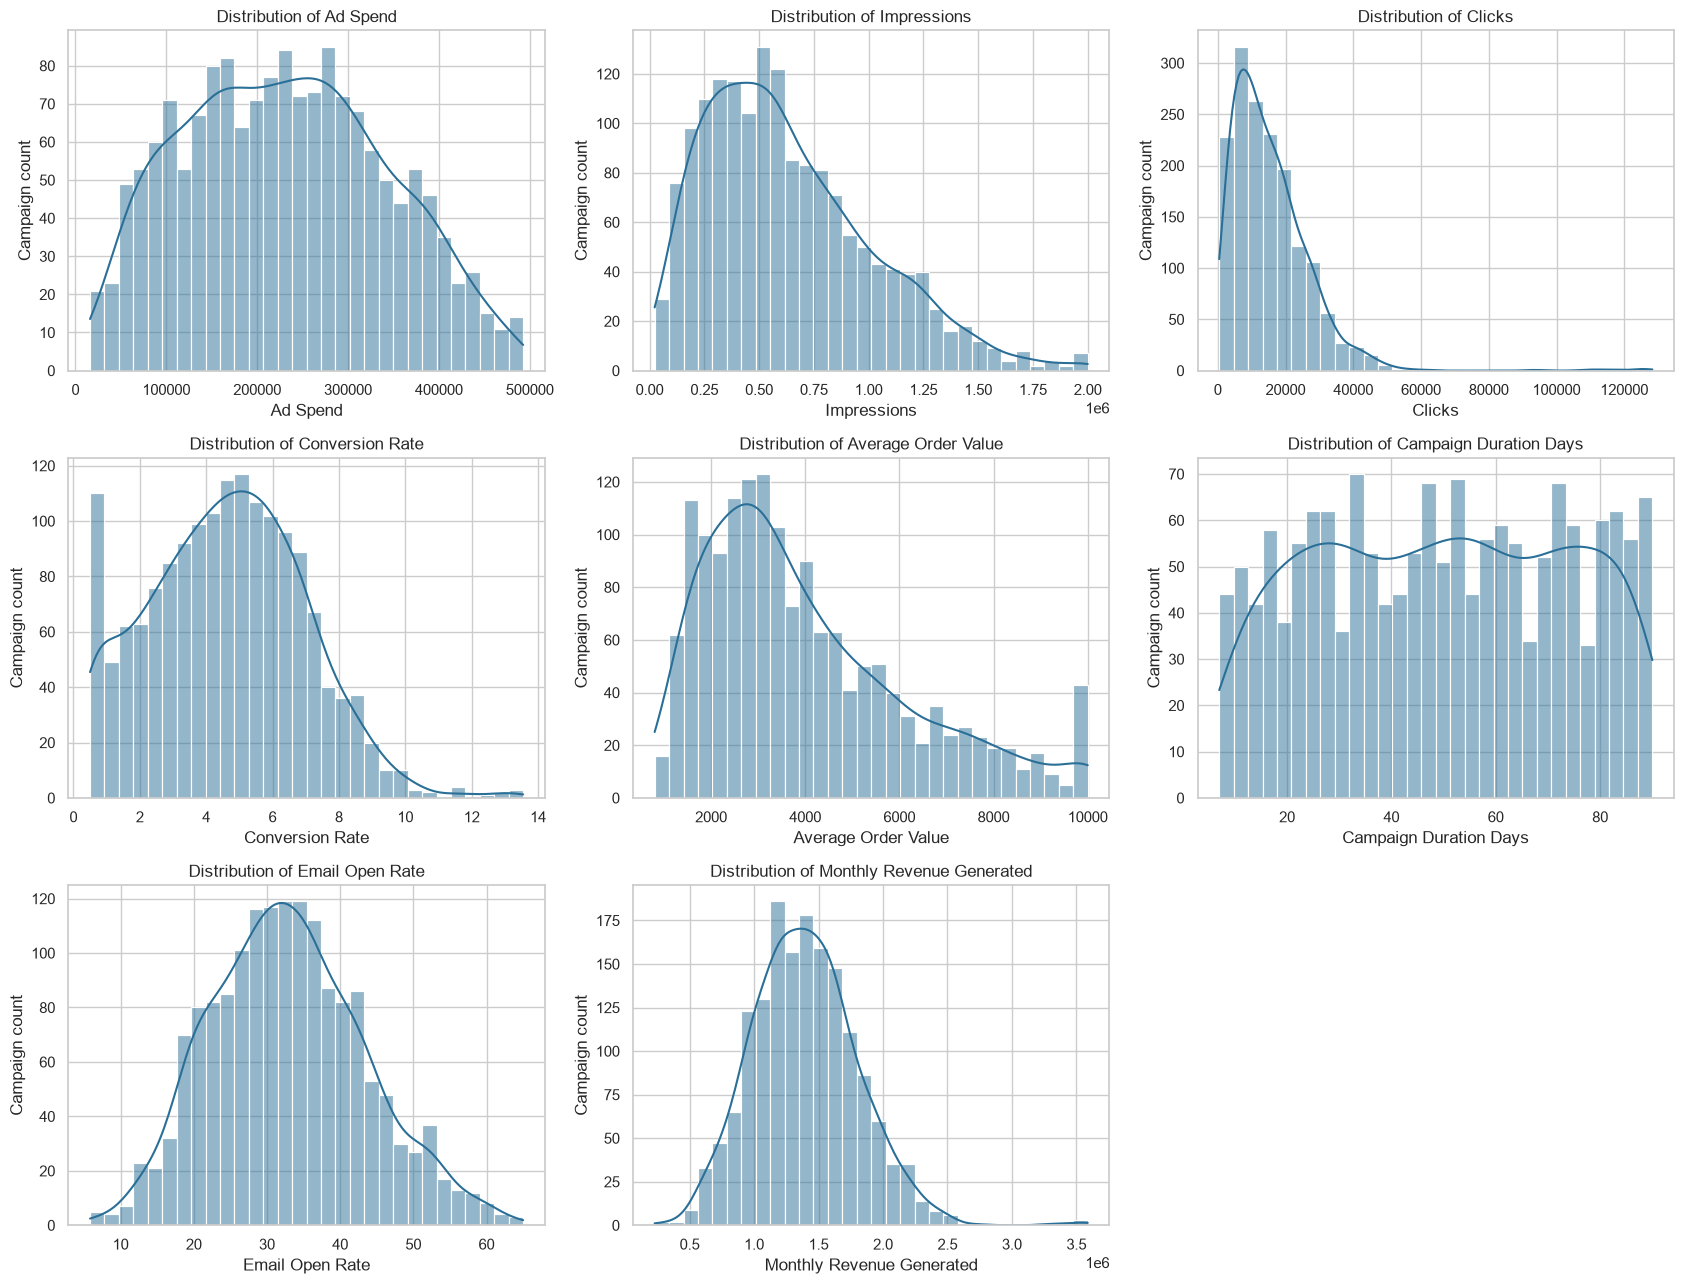

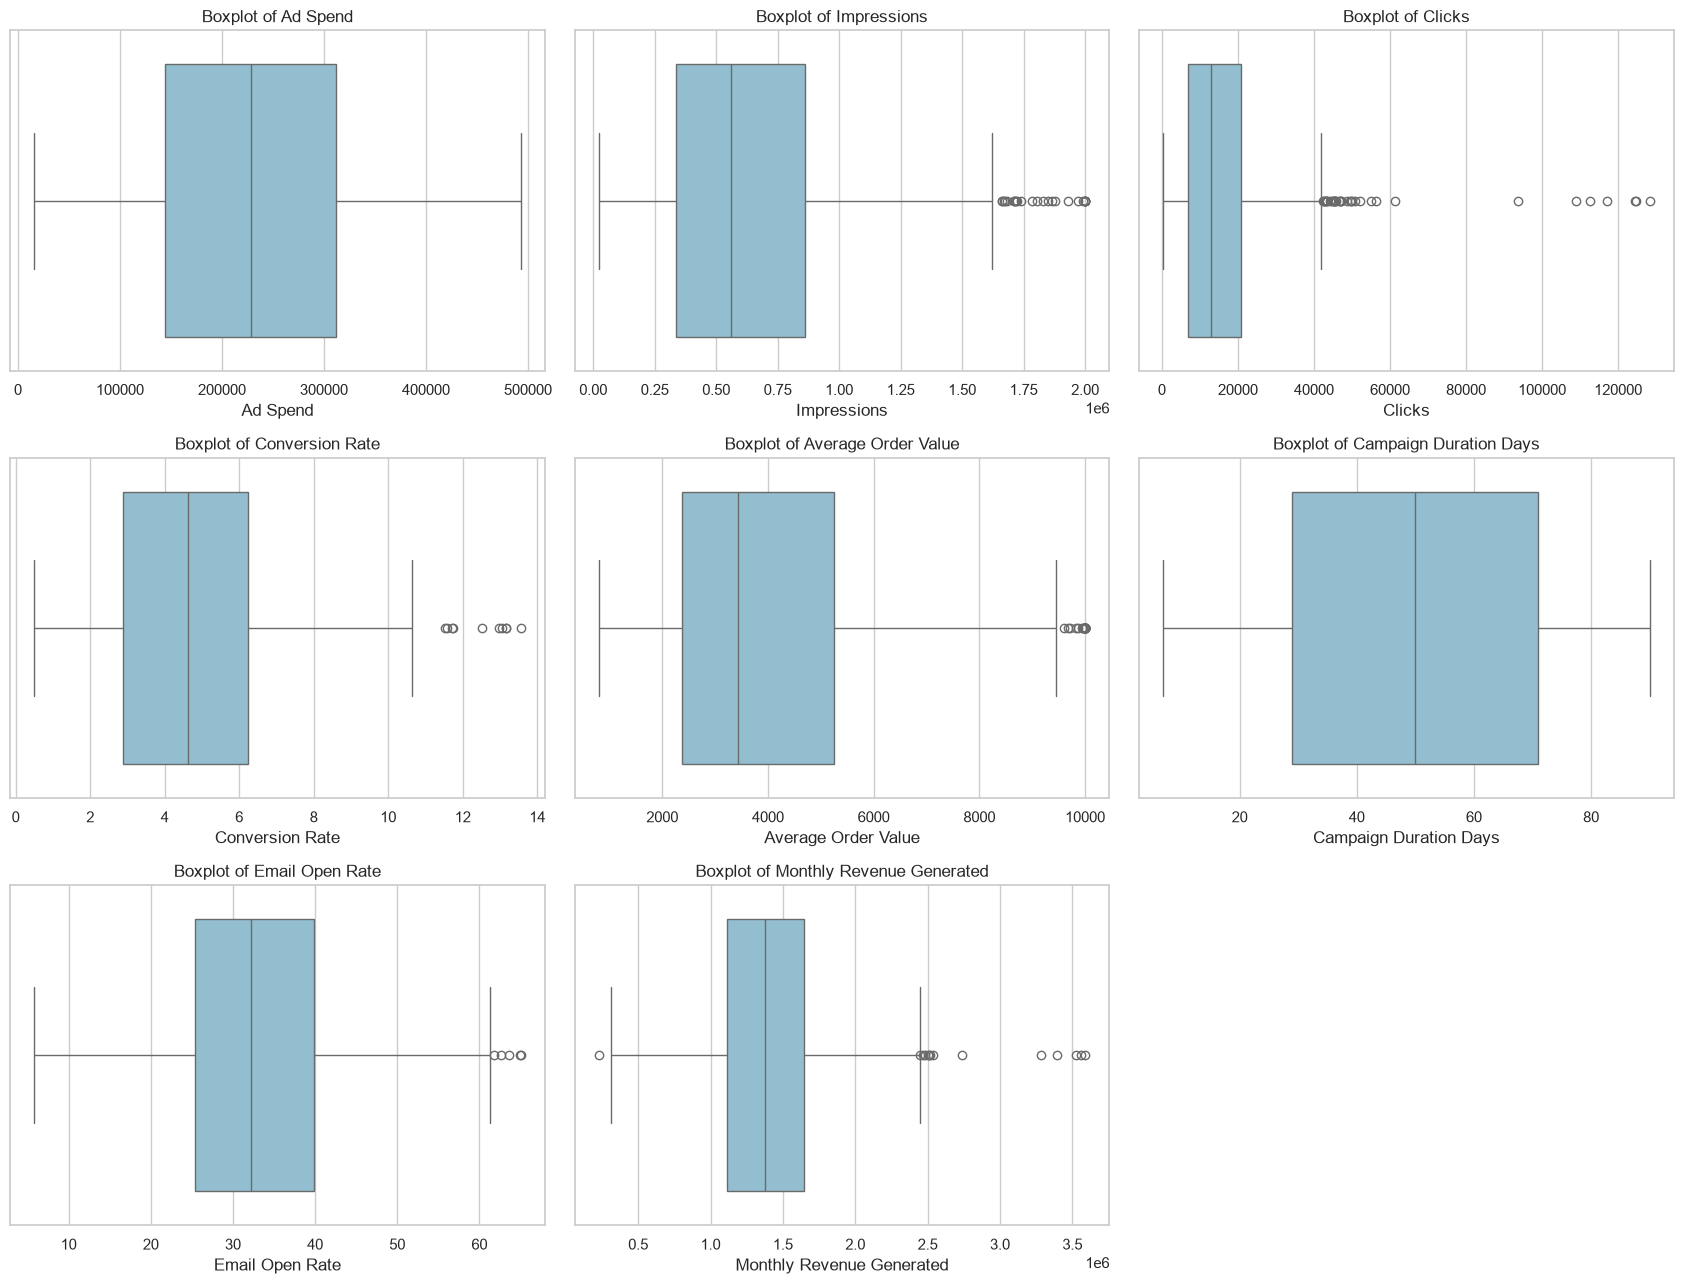

In [18]:
# Combine training predictors and target for EDA without touching the test set.
eda_train = X_train.copy()
eda_train[target_column] = y_train
plot_variables = numerical_predictors + [target_column]

# Draw a histogram for every numerical predictor and the target.
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
for axis, column in zip(axes.flat, plot_variables):
    sns.histplot(eda_train[column], bins=30, kde=True, ax=axis, color="#2A6F97")
    axis.set_title(f"Distribution of {column.replace('_', ' ')}")
    axis.set_xlabel(column.replace("_", " "))
    axis.set_ylabel("Campaign count")
for axis in axes.flat[len(plot_variables):]:
    axis.set_visible(False)
plt.tight_layout()
plt.show()

# Draw a boxplot for every numerical predictor and the target.
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
for axis, column in zip(axes.flat, plot_variables):
    sns.boxplot(x=eda_train[column], ax=axis, color="#89C2D9")
    axis.set_title(f"Boxplot of {column.replace('_', ' ')}")
    axis.set_xlabel(column.replace("_", " "))
for axis in axes.flat[len(plot_variables):]:
    axis.set_visible(False)
plt.tight_layout()
plt.show()

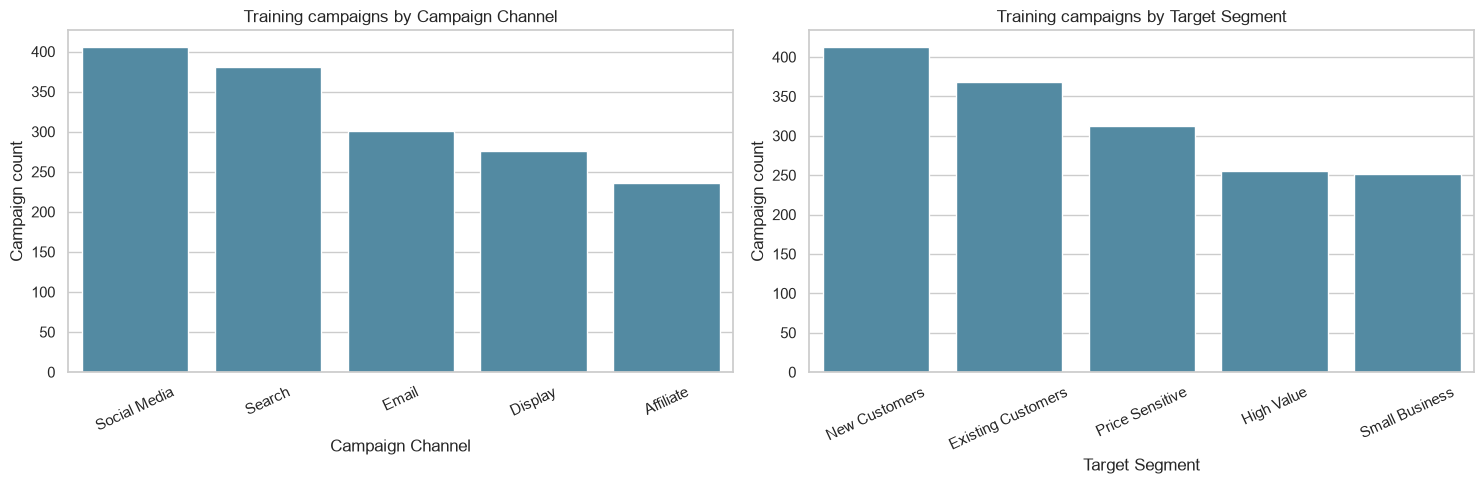

In [19]:
# Plot category frequencies in the training set.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for axis, column in zip(axes, categorical_predictors):
    category_order = eda_train[column].value_counts().index
    sns.countplot(data=eda_train, x=column, order=category_order, ax=axis, color="#468FAF")
    axis.set_title(f"Training campaigns by {column.replace('_', ' ')}")
    axis.set_xlabel(column.replace("_", " "))
    axis.set_ylabel("Campaign count")
    axis.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

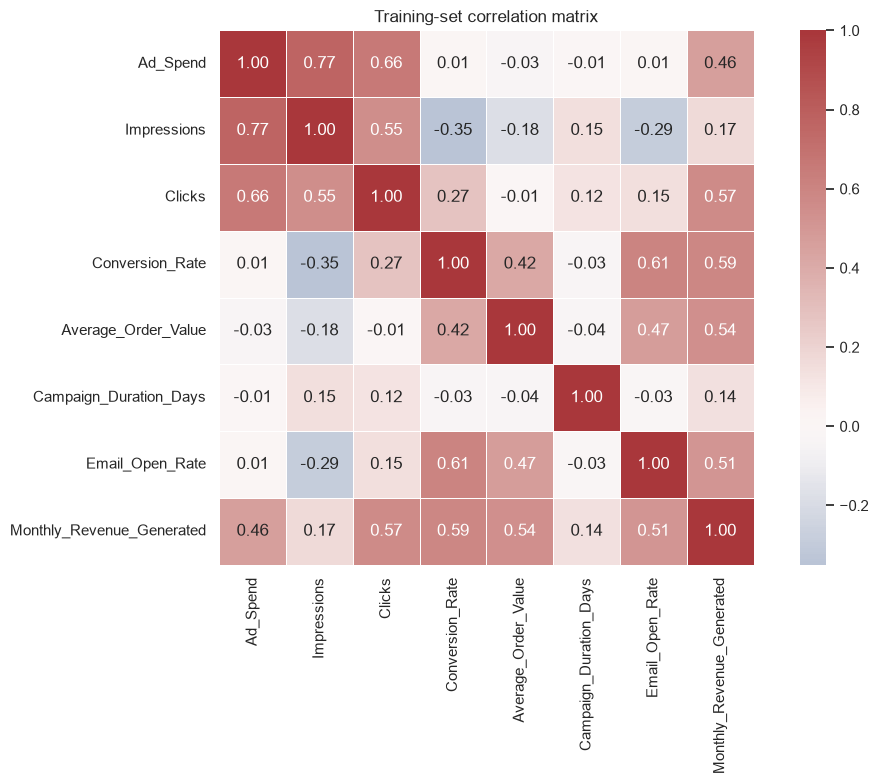

,Ad_Spend,Impressions,Clicks,Conversion_Rate,Average_Order_Value,Campaign_Duration_Days,Email_Open_Rate,Monthly_Revenue_Generated
Ad_Spend,1.00,0.77,0.66,0.01,-0.03,-0.01,0.01,0.46
Impressions,0.77,1.00,0.55,-0.35,-0.18,0.15,-0.29,0.17
Clicks,0.66,0.55,1.00,0.27,-0.01,0.12,0.15,0.57
Conversion_Rate,0.01,-0.35,0.27,1.00,0.42,-0.03,0.61,0.59
Average_Order_Value,-0.03,-0.18,-0.01,0.42,1.00,-0.04,0.47,0.54
Campaign_Duration_Days,-0.01,0.15,0.12,-0.03,-0.04,1.00,-0.03,0.14
Email_Open_Rate,0.01,-0.29,0.15,0.61,0.47,-0.03,1.00,0.51
Monthly_Revenue_Generated,0.46,0.17,0.57,0.59,0.54,0.14,0.51,1.00


In [20]:
# Calculate and plot Pearson correlations among numerical predictors and the target.
training_correlation_matrix = eda_train[plot_variables].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    training_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Training-set correlation matrix")
plt.tight_layout()
plt.show()

training_correlation_matrix

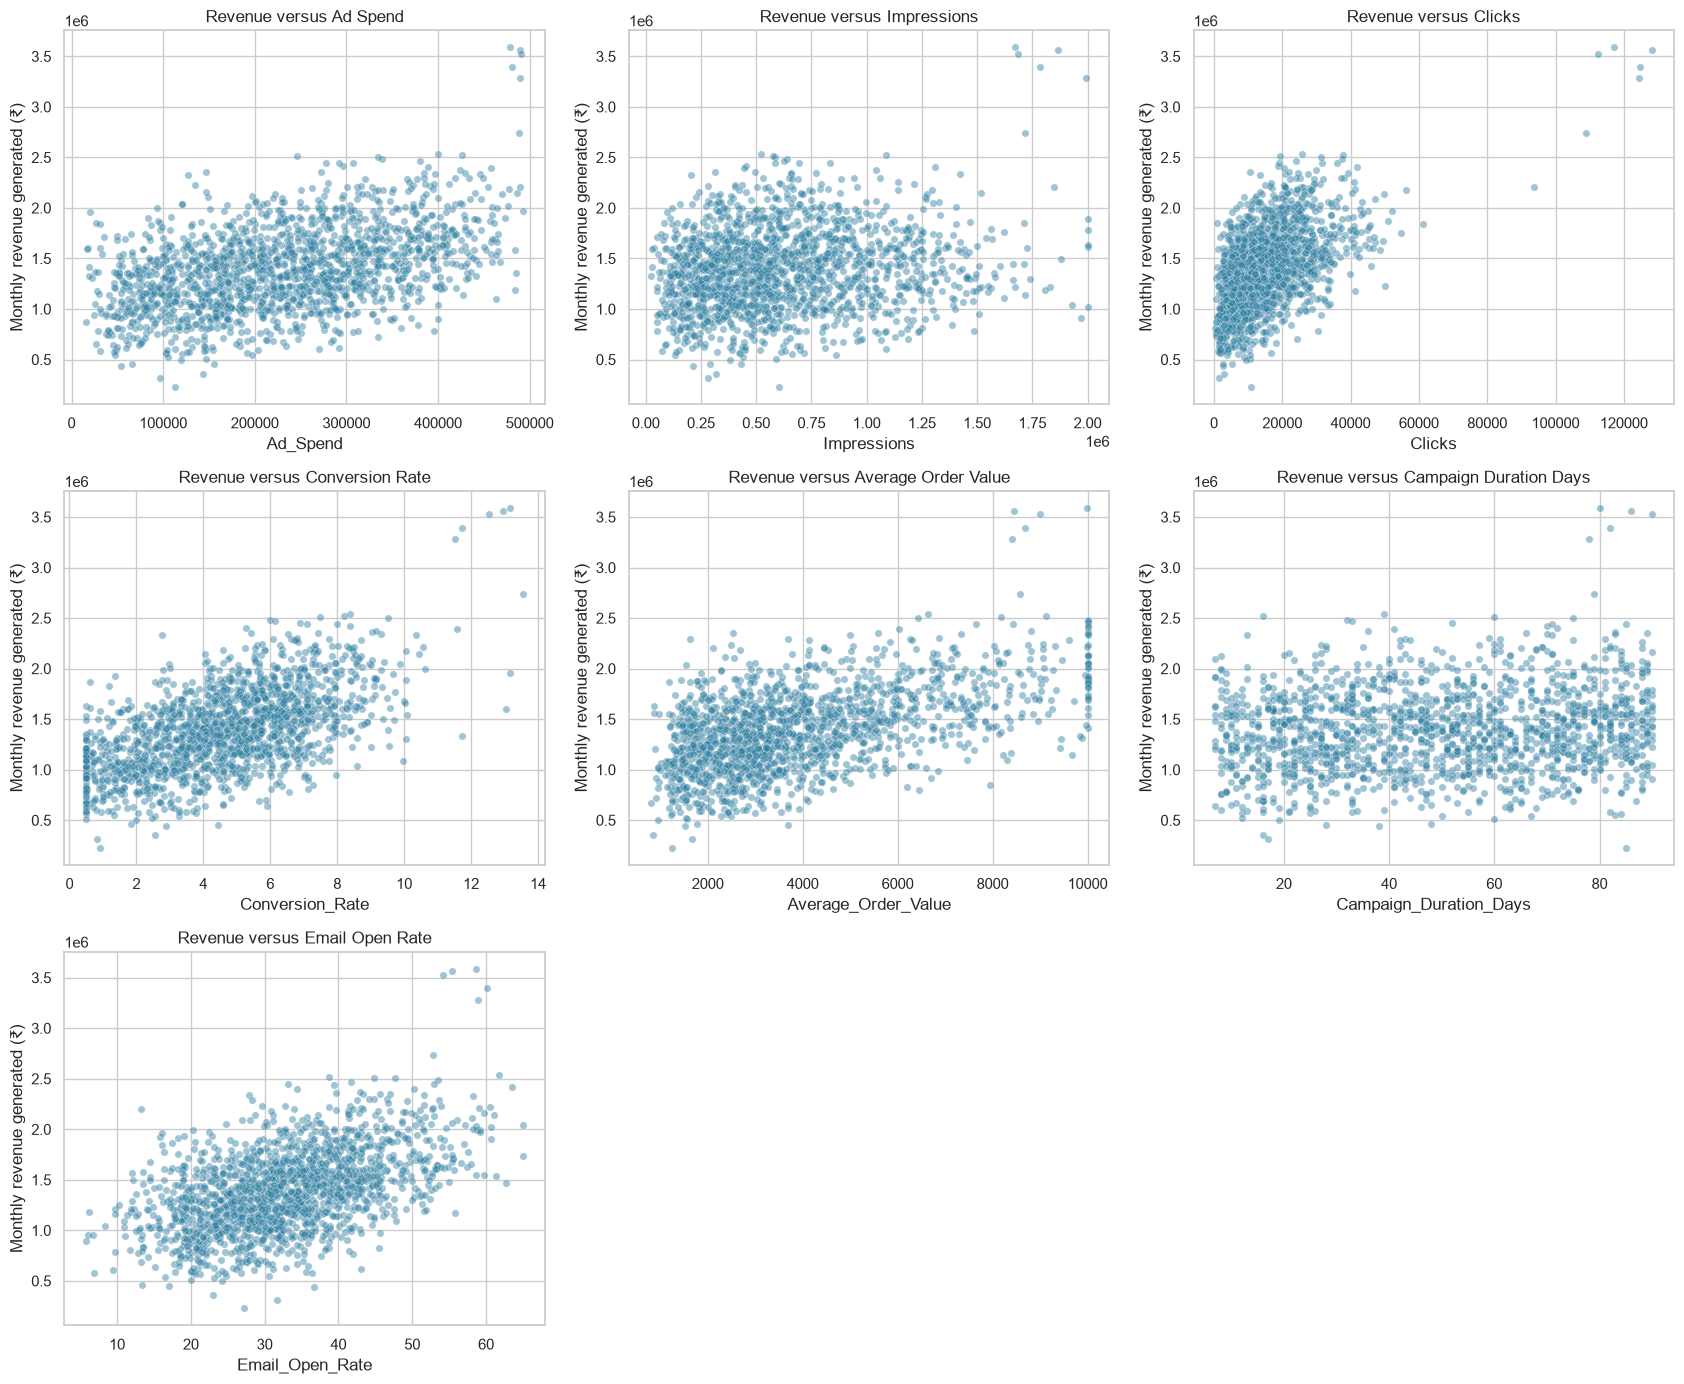

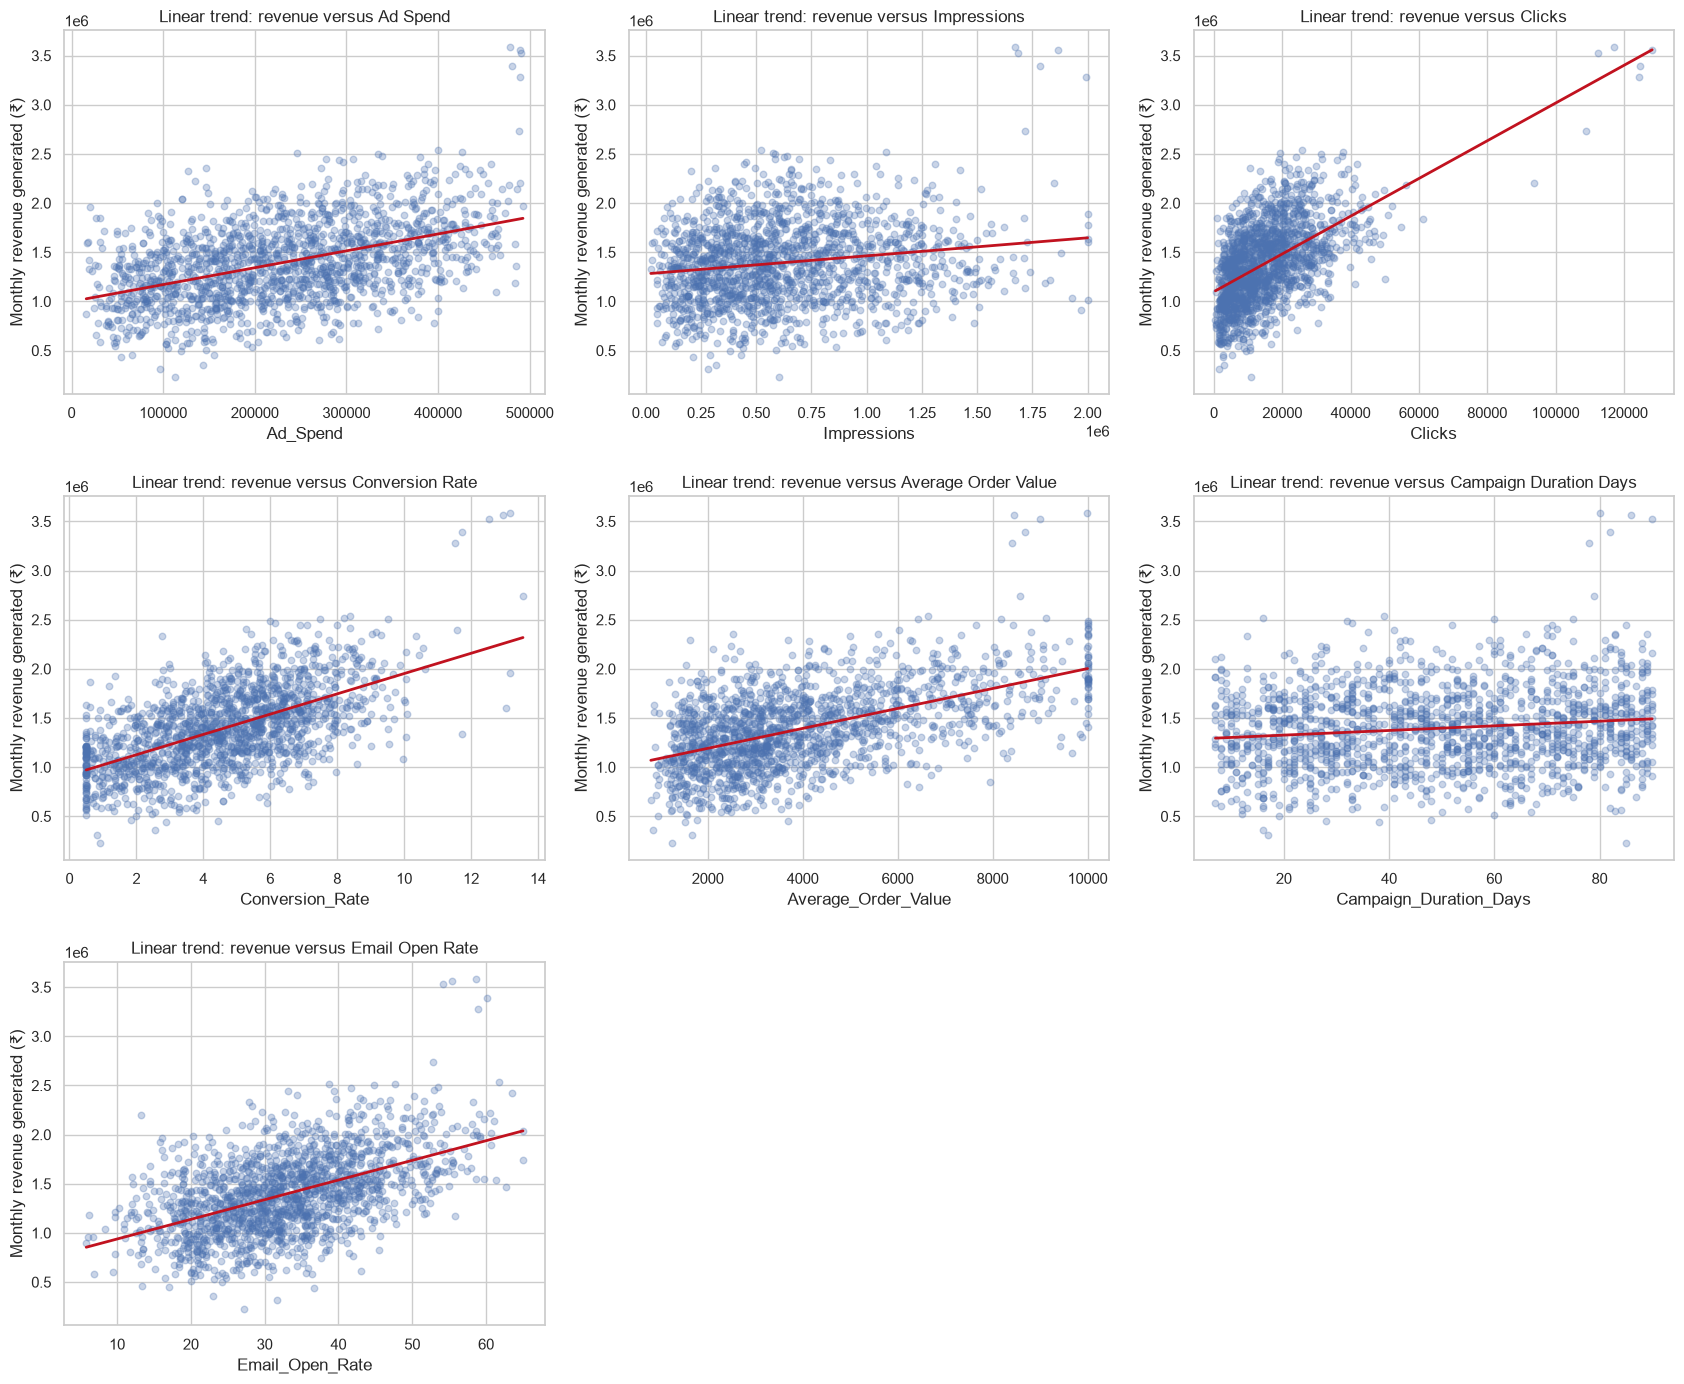

In [21]:
# Plot raw scatterplots for every continuous predictor against monthly revenue.
fig, axes = plt.subplots(3, 3, figsize=(17, 14))
for axis, column in zip(axes.flat, numerical_predictors):
    sns.scatterplot(
        data=eda_train,
        x=column,
        y=target_column,
        alpha=0.45,
        s=28,
        ax=axis,
        color="#2C7DA0",
    )
    axis.set_title(f"Revenue versus {column.replace('_', ' ')}")
    axis.set_ylabel("Monthly revenue generated (₹)")
for axis in axes.flat[len(numerical_predictors):]:
    axis.set_visible(False)
plt.tight_layout()
plt.show()

# Repeat the relationships with fitted linear trend lines as a visual linearity check.
fig, axes = plt.subplots(3, 3, figsize=(17, 14))
for axis, column in zip(axes.flat, numerical_predictors):
    sns.regplot(
        data=eda_train,
        x=column,
        y=target_column,
        scatter_kws={"alpha": 0.30, "s": 22},
        line_kws={"color": "#C1121F", "linewidth": 2},
        ci=None,
        ax=axis,
    )
    axis.set_title(f"Linear trend: revenue versus {column.replace('_', ' ')}")
    axis.set_ylabel("Monthly revenue generated (₹)")
for axis in axes.flat[len(numerical_predictors):]:
    axis.set_visible(False)
plt.tight_layout()
plt.show()

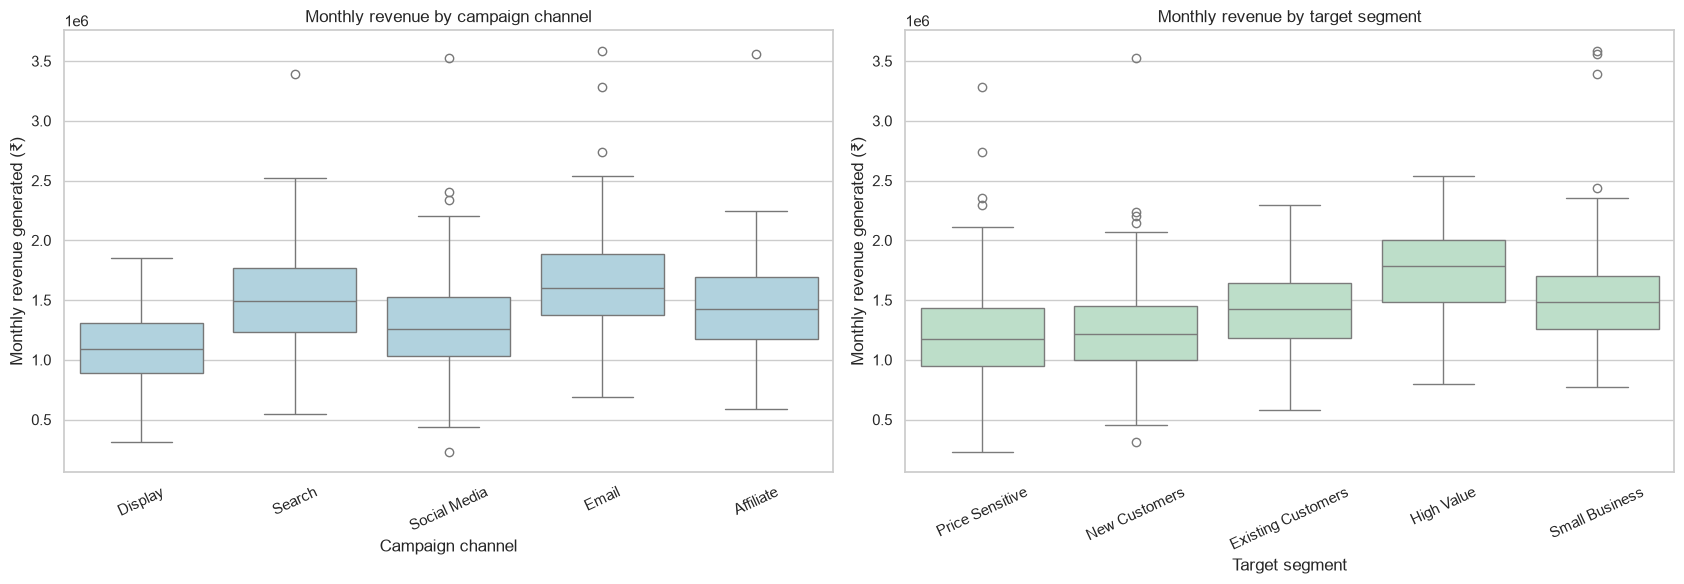

,count,mean,median,std
Campaign_Channel,,,,
Email,301,"1,636,126.06","1,598,271.55","398,770.77"
Search,381,"1,510,953.39","1,489,362.86","384,625.03"
Affiliate,236,"1,440,324.84","1,424,003.31","365,013.10"
Social Media,406,"1,284,201.48","1,261,341.58","373,955.99"
Display,276,"1,100,257.11","1,091,168.93","305,819.94"


,count,mean,median,std
Target_Segment,,,,
High Value,255,"1,764,467.02","1,783,580.85","355,283.88"
Small Business,251,"1,510,822.68","1,483,480.22","387,561.12"
Existing Customers,368,"1,413,653.87","1,421,537.65","342,470.74"
New Customers,413,"1,229,279.56","1,212,938.76","347,373.94"
Price Sensitive,313,"1,201,431.13","1,171,489.81","383,600.19"


In [22]:
# Compare revenue distributions across channels and customer segments.
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.boxplot(
    data=eda_train,
    x="Campaign_Channel",
    y=target_column,
    ax=axes[0],
    color="#A9D6E5",
)
axes[0].set_title("Monthly revenue by campaign channel")
axes[0].set_xlabel("Campaign channel")
axes[0].set_ylabel("Monthly revenue generated (₹)")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(
    data=eda_train,
    x="Target_Segment",
    y=target_column,
    ax=axes[1],
    color="#B7E4C7",
)
axes[1].set_title("Monthly revenue by target segment")
axes[1].set_xlabel("Target segment")
axes[1].set_ylabel("Monthly revenue generated (₹)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

channel_revenue_summary = (
    eda_train.groupby("Campaign_Channel")[target_column]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)
segment_revenue_summary = (
    eda_train.groupby("Target_Segment")[target_column]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)
display(channel_revenue_summary)
display(segment_revenue_summary)

,Skewness,Interpretation
Clicks,3.06,Strong
Average_Order_Value,0.97,Moderate
Impressions,0.86,Moderate
Monthly_Revenue_Generated,0.55,Moderate
Email_Open_Rate,0.28,Low
Conversion_Rate,0.23,Low
Ad_Spend,0.17,Low
Campaign_Duration_Days,-0.02,Low


Strongly right-skewed positive variables: ['Clicks']


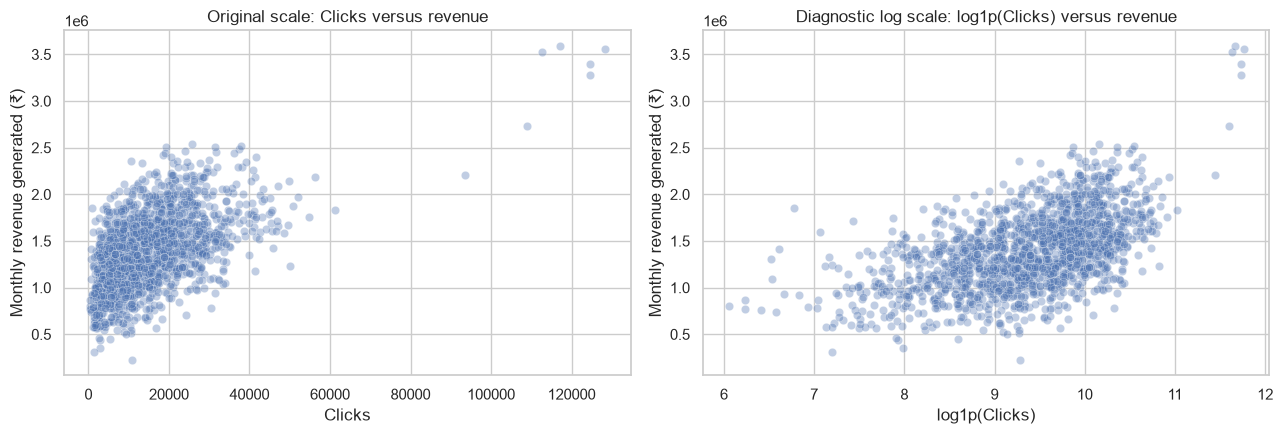

In [23]:
# Quantify skewness and identify only strongly right-skewed positive variables.
training_skewness = eda_train[plot_variables].skew().sort_values(ascending=False)
skewness_table = training_skewness.rename("Skewness").to_frame()
skewness_table["Interpretation"] = pd.cut(
    skewness_table["Skewness"].abs(),
    bins=[-np.inf, 0.5, 1.0, np.inf],
    labels=["Low", "Moderate", "Strong"],
)
display(skewness_table)

strongly_right_skewed = [
    column
    for column in plot_variables
    if training_skewness[column] > 1 and (eda_train[column] > 0).all()
]
print("Strongly right-skewed positive variables:", strongly_right_skewed)

# Log plots are diagnostic only; no transformation is applied at this stage.
for column in strongly_right_skewed:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.scatterplot(data=eda_train, x=column, y=target_column, alpha=0.35, ax=axes[0])
    axes[0].set_title(f"Original scale: {column} versus revenue")
    axes[0].set_ylabel("Monthly revenue generated (₹)")
    sns.scatterplot(
        x=np.log1p(eda_train[column]),
        y=eda_train[target_column],
        alpha=0.35,
        ax=axes[1],
    )
    axes[1].set_title(f"Diagnostic log scale: log1p({column}) versus revenue")
    axes[1].set_xlabel(f"log1p({column})")
    axes[1].set_ylabel("Monthly revenue generated (₹)")
    plt.tight_layout()
    plt.show()

## EDA interpretation

- `Clicks` is strongly right-skewed in the training data (skewness about 3.06). `Average_Order_Value` and `Impressions` are moderately right-skewed, while the target is only mildly right-skewed. Predictor normality is **not** an assumption of multiple linear regression.
- The scatterplots show broadly increasing revenue trends for spend, clicks, conversion rate, order value, duration, and email open rate. `Impressions` has a weaker marginal trend because it overlaps substantially with spend and click information.
- Channel and segment distributions show meaningful level differences. Email and Search campaigns have higher average revenue than Display campaigns; High Value and Small Business segments have higher average revenue than Price Sensitive and New Customer segments. These are associations, not causal effects.
- The optional `log1p(Clicks)` plot is retained as a visual sensitivity check. A log transform is not selected solely because clicks are skewed; the raw-scale relationship and later residual diagnostics determine whether it is needed.

Overall, the target–predictor relationships appear reasonably compatible with an initial multiple linear regression. The model still requires residual, variance, multicollinearity, and influence diagnostics.

# Step 5 — Categorical treatment and multicollinearity

Both categorical predictors are nominal, so one-hot encoding is used. Explicit category orders establish transparent reference groups for the statsmodels diagnostic model: **Affiliate** for `Campaign_Channel` and **Existing Customers** for `Target_Segment`. Dropping one category from each set avoids the dummy-variable trap and does not impose an ordinal ranking.

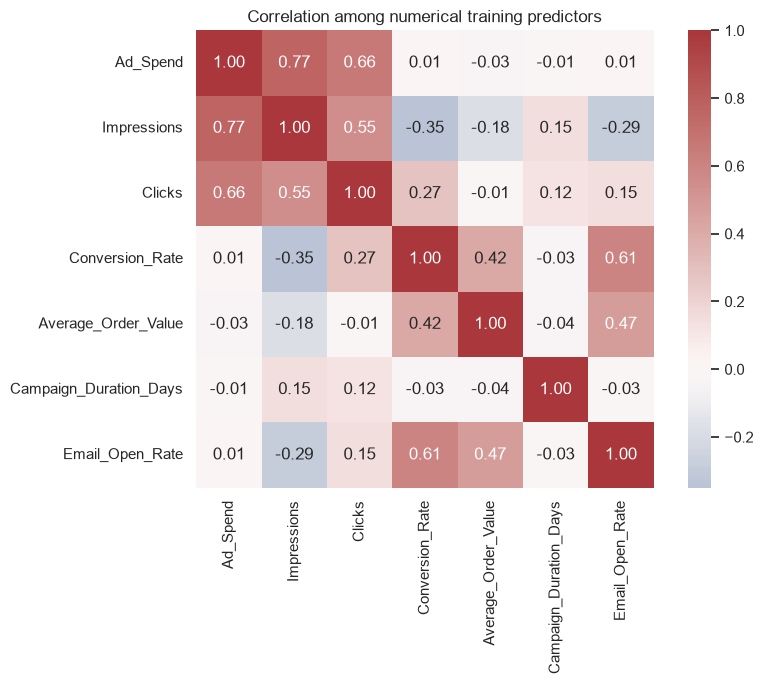

,Ad_Spend,Impressions,Clicks,Conversion_Rate,Average_Order_Value,Campaign_Duration_Days,Email_Open_Rate
Ad_Spend,1.00,0.77,0.66,0.01,-0.03,-0.01,0.01
Impressions,0.77,1.00,0.55,-0.35,-0.18,0.15,-0.29
Clicks,0.66,0.55,1.00,0.27,-0.01,0.12,0.15
Conversion_Rate,0.01,-0.35,0.27,1.00,0.42,-0.03,0.61
Average_Order_Value,-0.03,-0.18,-0.01,0.42,1.00,-0.04,0.47
Campaign_Duration_Days,-0.01,0.15,0.12,-0.03,-0.04,1.00,-0.03
Email_Open_Rate,0.01,-0.29,0.15,0.61,0.47,-0.03,1.00


In [24]:
# Inspect correlation among numerical predictors using training data only.
numerical_predictor_correlation = X_train[numerical_predictors].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    numerical_predictor_correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
)
plt.title("Correlation among numerical training predictors")
plt.tight_layout()
plt.show()

numerical_predictor_correlation

In [25]:
# Create a reference-coded diagnostic matrix for statsmodels and VIF analysis.
from statsmodels.stats.outliers_influence import variance_inflation_factor

campaign_category_order = ["Affiliate", "Display", "Email", "Search", "Social Media"]
segment_category_order = [
    "Existing Customers",
    "High Value",
    "New Customers",
    "Price Sensitive",
    "Small Business",
]

X_train_diagnostic = X_train.copy()
X_train_diagnostic["Campaign_Channel"] = pd.Categorical(
    X_train_diagnostic["Campaign_Channel"],
    categories=campaign_category_order,
)
X_train_diagnostic["Target_Segment"] = pd.Categorical(
    X_train_diagnostic["Target_Segment"],
    categories=segment_category_order,
)

X_train_encoded = pd.get_dummies(
    X_train_diagnostic,
    columns=categorical_predictors,
    drop_first=True,
    dtype=float,
)
X_train_sm = sm.add_constant(X_train_encoded, has_constant="add")

print("Reference category for Campaign_Channel: Affiliate")
print("Reference category for Target_Segment: Existing Customers")
print("Diagnostic matrix shape:", X_train_sm.shape)
print("Encoded predictors:", X_train_encoded.columns.tolist())

Reference category for Campaign_Channel: Affiliate
Reference category for Target_Segment: Existing Customers
Diagnostic matrix shape: (1600, 16)
Encoded predictors: ['Ad_Spend', 'Impressions', 'Clicks', 'Conversion_Rate', 'Average_Order_Value', 'Campaign_Duration_Days', 'Email_Open_Rate', 'Campaign_Channel_Display', 'Campaign_Channel_Email', 'Campaign_Channel_Search', 'Campaign_Channel_Social Media', 'Target_Segment_High Value', 'Target_Segment_New Customers', 'Target_Segment_Price Sensitive', 'Target_Segment_Small Business']


In [26]:
# Calculate VIF with an intercept, then classify practical redundancy levels.
def calculate_vif(encoded_predictors):
    design_with_constant = sm.add_constant(encoded_predictors, has_constant="add")
    table = pd.DataFrame(
        {
            "Feature": encoded_predictors.columns,
            "VIF": [
                variance_inflation_factor(design_with_constant.values, index + 1)
                for index in range(encoded_predictors.shape[1])
            ],
        }
    ).sort_values("VIF", ascending=False, ignore_index=True)
    table["Flag"] = np.select(
        [table["VIF"].ge(10), table["VIF"].ge(5)],
        ["Severe redundancy", "Elevated; inspect"],
        default="Acceptable",
    )
    return table


initial_vif_table = calculate_vif(X_train_encoded)
display(initial_vif_table)

,Feature,VIF,Flag
0,Impressions,6.93,Elevated; inspect
1,Ad_Spend,4.82,Acceptable
2,Average_Order_Value,4.47,Acceptable
3,Conversion_Rate,3.88,Acceptable
4,Campaign_Channel_Display,3.61,Acceptable
5,Target_Segment_High Value,3.36,Acceptable
6,Campaign_Channel_Social Media,3.19,Acceptable
7,Clicks,3.15,Acceptable
8,Email_Open_Rate,3.11,Acceptable
9,Target_Segment_Price Sensitive,2.96,Acceptable


## Multicollinearity interpretation and decision

The largest VIF is approximately **6.93 for `Impressions`**, which is elevated but below the commonly used severe-redundancy threshold of 10. `Ad_Spend` is approximately 4.82, and all remaining predictors are below 5.

This pattern is plausible: spending drives impressions, and impressions contribute to clicks. However, these variables represent distinct business stages and the values do not show severe redundancy. Therefore:

- no predictor is automatically deleted;
- `Impressions`, `Ad_Spend`, and `Clicks` are retained for the initial diagnostic model;
- the small conditional coefficient or statistical significance of one funnel variable will be interpreted in the presence of the others rather than treated as proof that the variable has no business value;
- no transformation or combination is applied until residual and influence results are reviewed.

# Step 6 — Initial regression and assumption diagnostics

An initial statsmodels OLS regression is fitted on the training data for diagnostic purposes. This is not yet the final deployment pipeline.

In [27]:
# Fit the initial diagnostic multiple linear regression on training data only.
initial_ols_model = sm.OLS(y_train, X_train_sm).fit()
initial_ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     Monthly_Revenue_Generated   R-squared:                       0.753
Model:                                   OLS   Adj. R-squared:                  0.751
Method:                        Least Squares   F-statistic:                     321.8
Date:                       Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                               20:22:44   Log-Likelihood:                -21832.
No. Observations:                       1600   AIC:                         4.370e+04
Df Residuals:                           1584   BIC:                         4.378e+04
Df Model:                                 15                                         
Covariance Type:                   nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           4.544e+05   5.06e+04      8.988      0.000    3.55e+05    5.54e+05
Ad_Spend                           1.1343      0.102     11.156      0.000       0.935       1.334
Impressions                       -0.0258      0.035     -0.731      0.465      -0.095       0.043
Clicks                             9.5562      0.751     12.716      0.000       8.082      11.030
Conversion_Rate                 3.351e+04   4317.265      7.761      0.000     2.5e+04     4.2e+04
Average_Order_Value               48.4369      4.948      9.790      0.000      38.733      58.141
Campaign_Duration_Days          2377.1992    229.941     10.338      0.000    1926.178    2828.221
Email_Open_Rate                 3057.2917    861.268      3.550      0.000    1367.947    4746.636
Campaign_Channel_Display       -9.692e+04   2.58e+04     -3.757      0.000   -1.48e+05   -4.63e+04
Campaign_Channel_Email          4.112e+04   2.23e+04      1.842      0.066   -2671.501    8.49e+04
Campaign_Channel_Search         1.948e+04   1.78e+04      1.094      0.274   -1.54e+04    5.44e+04
Campaign_Channel_Social Media  -6.411e+04    2.1e+04     -3.047      0.002   -1.05e+05   -2.28e+04
Target_Segment_High Value       1.382e+05   2.57e+04      5.381      0.000    8.78e+04    1.89e+05
Target_Segment_New Customers   -5.187e+04   1.97e+04     -2.629      0.009   -9.06e+04   -1.32e+04
Target_Segment_Price Sensitive -9.422e+04   2.22e+04     -4.238      0.000   -1.38e+05   -5.06e+04
Target_Segment_Small Business   7.123e+04   1.96e+04      3.628      0.000    3.27e+04     1.1e+05
==============================================================================
Omnibus:                        0.501   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.778   Jarque-Bera (JB):                0.405
Skew:                          -0.003   Prob(JB):                        0.816
Kurtosis:                       3.078   Cond. No.                     9.05e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.05e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

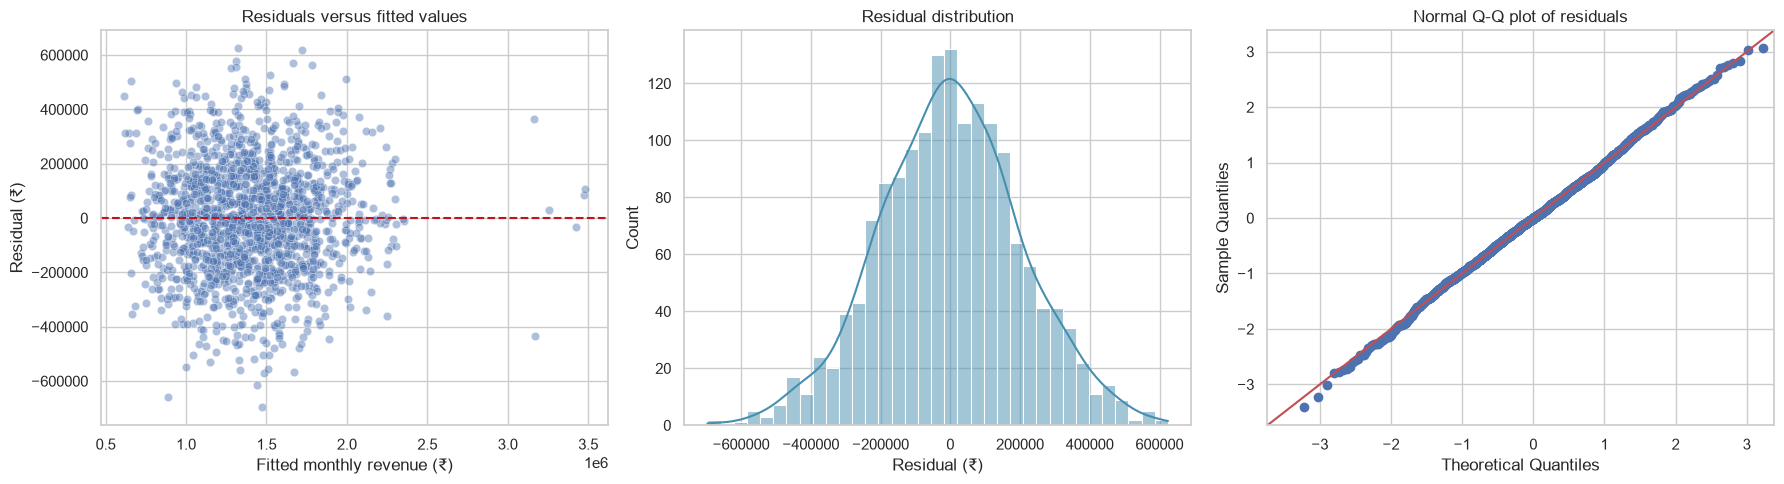

In [28]:
# Calculate fitted values and residuals and inspect their main diagnostic plots.
initial_fitted = initial_ols_model.fittedvalues
initial_residuals = initial_ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=initial_fitted, y=initial_residuals, alpha=0.45, ax=axes[0])
axes[0].axhline(0, color="#C1121F", linestyle="--")
axes[0].set_title("Residuals versus fitted values")
axes[0].set_xlabel("Fitted monthly revenue (₹)")
axes[0].set_ylabel("Residual (₹)")

sns.histplot(initial_residuals, bins=35, kde=True, ax=axes[1], color="#468FAF")
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residual (₹)")

sm.qqplot(initial_residuals, line="45", fit=True, ax=axes[2])
axes[2].set_title("Normal Q-Q plot of residuals")

plt.tight_layout()
plt.show()

In [29]:
# Calculate independence, variance, studentized-residual, leverage, and influence diagnostics.
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

initial_influence = initial_ols_model.get_influence()
studentized_residuals = initial_influence.resid_studentized_external
leverage_values = initial_influence.hat_matrix_diag
cooks_distance = initial_influence.cooks_distance[0]

n_train = len(X_train_sm)
n_parameters = X_train_sm.shape[1]
studentized_threshold = 3.0
leverage_threshold = 2 * n_parameters / n_train
cooks_threshold = 4 / n_train

durbin_watson_value = float(durbin_watson(initial_residuals))
bp_lm, bp_lm_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(
    initial_residuals, X_train_sm
)

diagnostic_test_table = pd.DataFrame(
    {
        "Diagnostic": [
            "Durbin-Watson",
            "Breusch-Pagan LM",
            "Breusch-Pagan F",
        ],
        "Statistic": [durbin_watson_value, bp_lm, bp_f],
        "P_Value": [np.nan, bp_lm_pvalue, bp_f_pvalue],
    }
)
display(diagnostic_test_table)

influence_diagnostics = pd.DataFrame(
    {
        "Campaign_ID": id_train.loc[X_train_sm.index],
        "Fitted_Revenue": initial_fitted,
        "Residual": initial_residuals,
        "Studentized_Residual": studentized_residuals,
        "Leverage": leverage_values,
        "Cooks_Distance": cooks_distance,
    },
    index=X_train_sm.index,
)
influence_diagnostics["Large_Studentized_Residual"] = (
    influence_diagnostics["Studentized_Residual"].abs() > studentized_threshold
)
influence_diagnostics["High_Leverage"] = (
    influence_diagnostics["Leverage"] > leverage_threshold
)
influence_diagnostics["Cooks_Above_4_over_n"] = (
    influence_diagnostics["Cooks_Distance"] > cooks_threshold
)
influence_diagnostics["Flagged_By_Any_Rule"] = influence_diagnostics[
    ["Large_Studentized_Residual", "High_Leverage", "Cooks_Above_4_over_n"]
].any(axis=1)

influence_count_table = pd.DataFrame(
    {
        "Rule": [
            f"|Studentized residual| > {studentized_threshold:.0f}",
            f"Leverage > 2p/n ({leverage_threshold:.4f})",
            f"Cook's distance > 4/n ({cooks_threshold:.4f})",
            "Flagged by at least one rule",
        ],
        "Count": [
            int(influence_diagnostics["Large_Studentized_Residual"].sum()),
            int(influence_diagnostics["High_Leverage"].sum()),
            int(influence_diagnostics["Cooks_Above_4_over_n"].sum()),
            int(influence_diagnostics["Flagged_By_Any_Rule"].sum()),
        ],
    }
)
display(influence_count_table)

# Display every flagged row identifier, ordered by Cook's distance.
flagged_influence_rows = (
    influence_diagnostics.loc[influence_diagnostics["Flagged_By_Any_Rule"]]
    .sort_values("Cooks_Distance", ascending=False)
)
display(flagged_influence_rows)

,Diagnostic,Statistic,P_Value
0,Durbin-Watson,1.99,NaN
1,Breusch-Pagan LM,15.41,0.42
2,Breusch-Pagan F,1.03,0.42


,Rule,Count
0,|Studentized residual| > 3,5
1,Leverage > 2p/n (0.0200),22
2,Cook's distance > 4/n (0.0025),80
3,Flagged by at least one rule,98


,Campaign_ID,Fitted_Revenue,Residual,Studentized_Residual,Leverage,Cooks_Distance,Large_Studentized_Residual,High_Leverage,Cooks_Above_4_over_n,Flagged_By_Any_Rule
1849,CMP1850,"3,161,827.95","365,916.38",1.90,0.12,0.03,False,True,True,True
1166,CMP1167,"3,170,832.02","-433,861.90",-2.21,0.08,0.03,False,True,True,True
833,CMP0834,"1,391,107.06","456,189.65",2.25,0.02,0.01,False,True,True,True
1051,CMP1052,"1,472,290.04","-696,565.62",-3.42,0.01,0.01,True,False,True,True
736,CMP0737,"1,718,103.80","616,742.05",3.03,0.01,0.01,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...
1167,CMP1168,"1,518,740.40","80,758.55",0.40,0.04,0.00,False,True,False,True
1517,CMP1518,"3,426,530.41","-33,265.17",-0.17,0.10,0.00,False,True,False,True
1586,CMP1587,"3,254,373.22","27,973.96",0.14,0.10,0.00,False,True,False,True
1011,CMP1012,"1,236,757.81","62,605.25",0.31,0.02,0.00,False,True,False,True


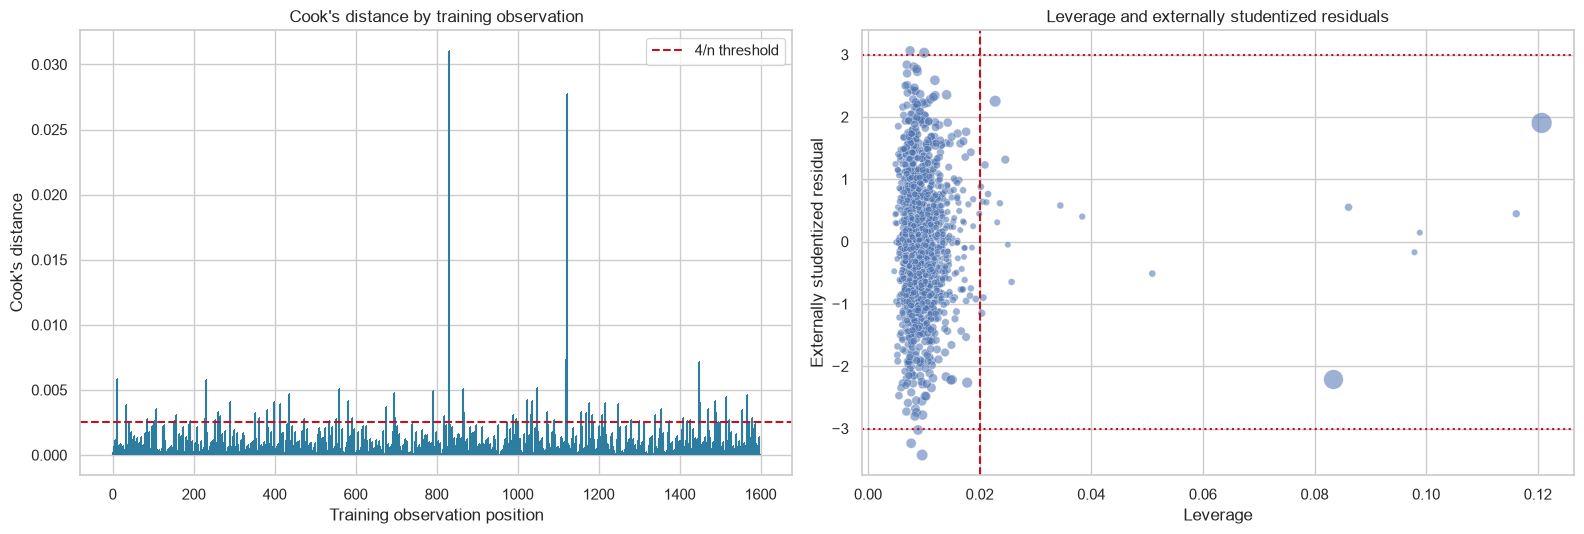

In [30]:
# Visualise Cook's distance and the joint leverage/studentized-residual pattern.
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].stem(
    np.arange(n_train),
    cooks_distance,
    markerfmt=",",
    linefmt="#2C7DA0",
    basefmt=" ",
)
axes[0].axhline(cooks_threshold, color="#C1121F", linestyle="--", label="4/n threshold")
axes[0].set_title("Cook's distance by training observation")
axes[0].set_xlabel("Training observation position")
axes[0].set_ylabel("Cook's distance")
axes[0].legend()

point_sizes = 25 + 1800 * cooks_distance
sns.scatterplot(
    x=leverage_values,
    y=studentized_residuals,
    size=point_sizes,
    sizes=(20, 220),
    legend=False,
    alpha=0.55,
    ax=axes[1],
)
axes[1].axvline(leverage_threshold, color="#C1121F", linestyle="--")
axes[1].axhline(studentized_threshold, color="#C1121F", linestyle=":")
axes[1].axhline(-studentized_threshold, color="#C1121F", linestyle=":")
axes[1].set_title("Leverage and externally studentized residuals")
axes[1].set_xlabel("Leverage")
axes[1].set_ylabel("Externally studentized residual")

plt.tight_layout()
plt.show()

## Initial diagnostic interpretation

- **Model fit:** training R² is approximately **0.753** and adjusted R² is **0.751**, so the linear specification explains a substantial but non-perfect share of training revenue variation.
- **Linearity and variance:** the residual-versus-fitted plot is centered around zero without a dominant curve or strong funnel pattern. The Breusch–Pagan p-value is approximately **0.42**, so there is no strong evidence of systematic heteroscedasticity.
- **Residual normality:** the histogram and Q-Q plot are broadly compatible with a near-normal centre but show some tail departures. Five observations have externally studentized residual magnitudes above 3. Exact residual normality is not required for unbiased OLS predictions, but tails matter for classical inference.
- **Independence:** Durbin–Watson is approximately **1.99**, close to 2. There is no practical evidence of first-order residual autocorrelation. Campaign rows are cross-sectional, so ordering should still not be given a time-series interpretation.
- **Influence:** 22 rows exceed the `2p/n` leverage guideline and 80 exceed the sensitive `4/n` Cook's-distance screening rule. The maximum Cook's distance is only about **0.031**, far below 1. These rules identify observations for review, not automatic deletion. The campaign IDs are retained in the displayed table for traceability.

# Step 7 — Corrections and re-checking assumptions

## Diagnosed issues and justified response

The diagnostics do **not** justify deleting rows, dropping a predictor, transforming the target, or forcing nonlinear terms:

- all audited observations are valid;
- no VIF reaches the severe threshold of 10;
- the residual plot does not show a strong nonlinear pattern;
- the Breusch–Pagan test does not indicate material heteroscedasticity;
- Durbin–Watson is close to 2;
- influential-screening flags exist, but their absolute Cook's distances are modest.

Accordingly, the unmodified data and linear specification are retained. As a conservative inference sensitivity check, the regression is refitted with **HC3 heteroscedasticity-robust standard errors**. HC3 changes uncertainty estimates, not coefficients, predictions, residuals, VIF, or influence values. This avoids manipulating data merely to improve assumptions or R².

In [31]:
# Preserve data before corrections and refit the same specification with HC3 inference.
df_clean_before_corrections = df_clean.copy(deep=True)
X_train_before_corrections = X_train.copy(deep=True)
y_train_before_corrections = y_train.copy(deep=True)

corrected_ols_base = sm.OLS(y_train, X_train_sm).fit()
corrected_ols_hc3 = corrected_ols_base.get_robustcov_results(cov_type="HC3")

print("Rows before correction decisions:", len(df_clean_before_corrections))
print("Rows after correction decisions: ", len(df_clean))
print("Rows removed:                    ", len(df_clean_before_corrections) - len(df_clean))
print("Predictors removed:              None")
print("Transformations applied:         None")
print("Inference sensitivity method:    HC3 robust standard errors")

corrected_ols_hc3.summary()

Rows before correction decisions: 2000
Rows after correction decisions:  2000
Rows removed:                     0
Predictors removed:              None
Transformations applied:         None
Inference sensitivity method:    HC3 robust standard errors


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     Monthly_Revenue_Generated   R-squared:                       0.753
Model:                                   OLS   Adj. R-squared:                  0.751
Method:                        Least Squares   F-statistic:                     340.9
Date:                       Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                               20:22:46   Log-Likelihood:                -21832.
No. Observations:                       1600   AIC:                         4.370e+04
Df Residuals:                           1584   BIC:                         4.378e+04
Df Model:                                 15                                         
Covariance Type:                         HC3                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           4.544e+05   5.34e+04      8.501      0.000     3.5e+05    5.59e+05
Ad_Spend                           1.1343      0.101     11.215      0.000       0.936       1.333
Impressions                       -0.0258      0.036     -0.721      0.471      -0.096       0.044
Clicks                             9.5562      0.732     13.055      0.000       8.120      10.992
Conversion_Rate                 3.351e+04   4454.819      7.522      0.000    2.48e+04    4.22e+04
Average_Order_Value               48.4369      4.936      9.813      0.000      38.755      58.119
Campaign_Duration_Days          2377.1992    223.978     10.614      0.000    1937.874    2816.524
Email_Open_Rate                 3057.2917    856.537      3.569      0.000    1377.226    4737.357
Campaign_Channel_Display       -9.692e+04    2.7e+04     -3.589      0.000    -1.5e+05   -4.39e+04
Campaign_Channel_Email          4.112e+04   2.26e+04      1.819      0.069   -3217.235    8.55e+04
Campaign_Channel_Search         1.948e+04   1.78e+04      1.092      0.275   -1.55e+04    5.45e+04
Campaign_Channel_Social Media  -6.411e+04   2.09e+04     -3.069      0.002   -1.05e+05   -2.31e+04
Target_Segment_High Value       1.382e+05   2.59e+04      5.339      0.000    8.74e+04    1.89e+05
Target_Segment_New Customers   -5.187e+04   2.09e+04     -2.484      0.013   -9.28e+04   -1.09e+04
Target_Segment_Price Sensitive -9.422e+04   2.37e+04     -3.973      0.000   -1.41e+05   -4.77e+04
Target_Segment_Small Business   7.123e+04   1.94e+04      3.679      0.000    3.32e+04    1.09e+05
==============================================================================
Omnibus:                        0.501   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.778   Jarque-Bera (JB):                0.405
Skew:                          -0.003   Prob(JB):                        0.816
Kurtosis:                       3.078   Cond. No.                     9.05e+06
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 9.05e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
# Compare conventional and HC3 standard errors without changing coefficients.
standard_error_comparison = pd.DataFrame(
    {
        "Feature": corrected_ols_base.params.index,
        "Coefficient": corrected_ols_base.params.values,
        "Conventional_SE": corrected_ols_base.bse.values,
        "HC3_Robust_SE": np.asarray(corrected_ols_hc3.bse),
    }
)
standard_error_comparison["HC3_to_Conventional_SE_Ratio"] = (
    standard_error_comparison["HC3_Robust_SE"]
    / standard_error_comparison["Conventional_SE"]
)
display(standard_error_comparison)

,Feature,Coefficient,Conventional_SE,HC3_Robust_SE,HC3_to_Conventional_SE_Ratio
0,const,"454,394.19","50,557.34","53,449.14",1.06
1,Ad_Spend,1.13,0.10,0.10,0.99
2,Impressions,-0.03,0.04,0.04,1.01
3,Clicks,9.56,0.75,0.73,0.97
4,Conversion_Rate,"33,508.32","4,317.27","4,454.82",1.03
5,Average_Order_Value,48.44,4.95,4.94,1.00
6,Campaign_Duration_Days,"2,377.20",229.94,223.98,0.97
7,Email_Open_Rate,"3,057.29",861.27,856.54,0.99
8,Campaign_Channel_Display,"-96,917.24","25,795.05","27,007.50",1.05
9,Campaign_Channel_Email,"41,116.53","22,324.17","22,602.40",1.01


,Feature,VIF,Flag
0,Impressions,6.93,Elevated; inspect
1,Ad_Spend,4.82,Acceptable
2,Average_Order_Value,4.47,Acceptable
3,Conversion_Rate,3.88,Acceptable
4,Campaign_Channel_Display,3.61,Acceptable
5,Target_Segment_High Value,3.36,Acceptable
6,Campaign_Channel_Social Media,3.19,Acceptable
7,Clicks,3.15,Acceptable
8,Email_Open_Rate,3.11,Acceptable
9,Target_Segment_Price Sensitive,2.96,Acceptable


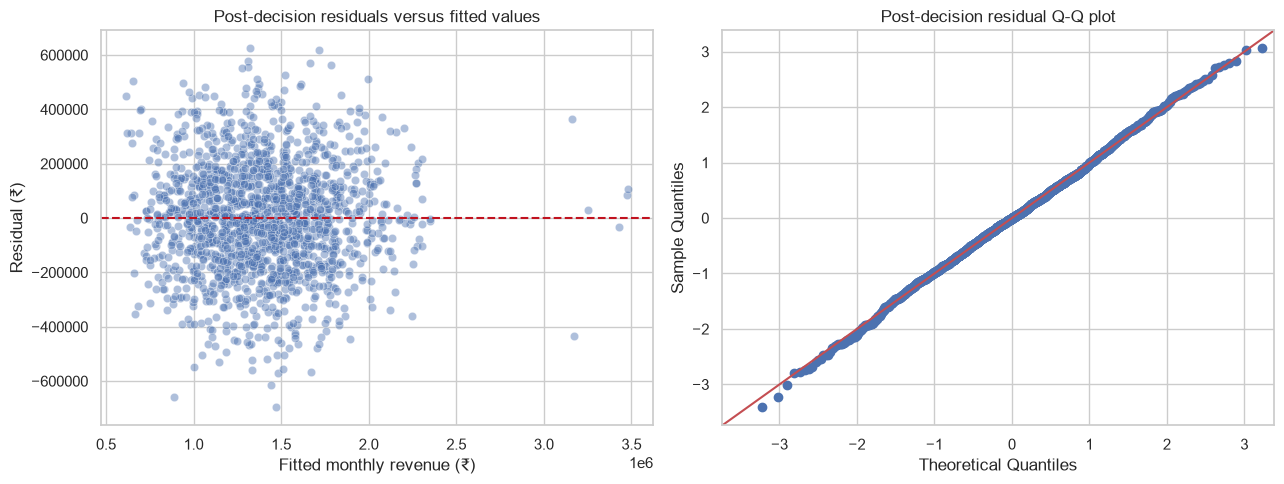

,Measure,Initial_OLS,Retained_Model_with_HC3_Inference
0,Rows,"1,600.00","1,600.00"
1,R-squared,0.75,0.75
2,Adjusted R-squared,0.75,0.75
3,Maximum VIF,6.93,6.93
4,Durbin-Watson,1.99,1.99
5,Breusch-Pagan LM p-value,0.42,0.42
6,|Studentized residual| > 3,5.00,5.00
7,Leverage > 2p/n,22.00,22.00
8,Cook's distance > 4/n,80.00,80.00
9,Maximum Cook's distance,0.03,0.03


,Campaign_ID,Studentized_Residual,Leverage,Cooks_Distance,Flagged
1849,CMP1850,1.90,0.12,0.03,True
1166,CMP1167,-2.21,0.08,0.03,True
833,CMP0834,2.25,0.02,0.01,True
1051,CMP1052,-3.42,0.01,0.01,True
736,CMP0737,3.03,0.01,0.01,True
...,...,...,...,...,...
1167,CMP1168,0.40,0.04,0.00,True
1517,CMP1518,-0.17,0.10,0.00,True
1586,CMP1587,0.14,0.10,0.00,True
1011,CMP1012,0.31,0.02,0.00,True


In [33]:
# Recalculate VIF, residual plots, formal tests, and influence diagnostics.
corrected_vif_table = calculate_vif(X_train_encoded)
display(corrected_vif_table)

corrected_fitted = corrected_ols_base.fittedvalues
corrected_residuals = corrected_ols_base.resid
corrected_influence = corrected_ols_base.get_influence()
corrected_studentized = corrected_influence.resid_studentized_external
corrected_leverage = corrected_influence.hat_matrix_diag
corrected_cooks = corrected_influence.cooks_distance[0]

corrected_dw = float(durbin_watson(corrected_residuals))
corrected_bp = het_breuschpagan(corrected_residuals, X_train_sm)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=corrected_fitted, y=corrected_residuals, alpha=0.45, ax=axes[0])
axes[0].axhline(0, color="#C1121F", linestyle="--")
axes[0].set_title("Post-decision residuals versus fitted values")
axes[0].set_xlabel("Fitted monthly revenue (₹)")
axes[0].set_ylabel("Residual (₹)")
sm.qqplot(corrected_residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Post-decision residual Q-Q plot")
plt.tight_layout()
plt.show()

corrected_influence_table = pd.DataFrame(
    {
        "Campaign_ID": id_train.loc[X_train_sm.index],
        "Studentized_Residual": corrected_studentized,
        "Leverage": corrected_leverage,
        "Cooks_Distance": corrected_cooks,
    },
    index=X_train_sm.index,
)
corrected_influence_table["Flagged"] = (
    corrected_influence_table["Studentized_Residual"].abs().gt(studentized_threshold)
    | corrected_influence_table["Leverage"].gt(leverage_threshold)
    | corrected_influence_table["Cooks_Distance"].gt(cooks_threshold)
)

before_after_diagnostics = pd.DataFrame(
    {
        "Measure": [
            "Rows",
            "R-squared",
            "Adjusted R-squared",
            "Maximum VIF",
            "Durbin-Watson",
            "Breusch-Pagan LM p-value",
            "|Studentized residual| > 3",
            "Leverage > 2p/n",
            "Cook's distance > 4/n",
            "Maximum Cook's distance",
        ],
        "Initial_OLS": [
            len(X_train),
            initial_ols_model.rsquared,
            initial_ols_model.rsquared_adj,
            initial_vif_table["VIF"].max(),
            durbin_watson_value,
            bp_lm_pvalue,
            int((np.abs(studentized_residuals) > studentized_threshold).sum()),
            int((leverage_values > leverage_threshold).sum()),
            int((cooks_distance > cooks_threshold).sum()),
            cooks_distance.max(),
        ],
        "Retained_Model_with_HC3_Inference": [
            len(X_train),
            corrected_ols_base.rsquared,
            corrected_ols_base.rsquared_adj,
            corrected_vif_table["VIF"].max(),
            corrected_dw,
            corrected_bp[1],
            int((np.abs(corrected_studentized) > studentized_threshold).sum()),
            int((corrected_leverage > leverage_threshold).sum()),
            int((corrected_cooks > cooks_threshold).sum()),
            corrected_cooks.max(),
        ],
    }
)
display(before_after_diagnostics)
display(
    corrected_influence_table.loc[corrected_influence_table["Flagged"]]
    .sort_values("Cooks_Distance", ascending=False)
)

## Correction conclusion and remaining limitations

The before-and-after diagnostics are intentionally unchanged because no observation, predictor, or functional form was altered. HC3 provides a more conservative inference check while preserving the same fitted values. The flagged campaigns remain because they are plausible observations rather than confirmed errors.

Remaining limitations include tail deviations, moderate overlap among funnel metrics, sensitivity of individual coefficients to correlated predictors, and the fact that the synthetic cross-sectional data cannot establish causality. Predictions should remain within the observed training ranges.

# Step 8 — Final pipeline, training, and evaluation

The final workflow uses `ColumnTransformer` and `Pipeline` so preprocessing is learned only from the training set and automatically reused for testing and future predictions. Numerical variables are standardized, and nominal categories are one-hot encoded with explicit reference categories and `handle_unknown="ignore"`. Multiple linear regression remains the primary model.

In [34]:
# Build and fit the final reproducible preprocessing-and-regression pipeline.
numerical_preprocessor = Pipeline(
    steps=[("standardize", StandardScaler())]
)
categorical_preprocessor = OneHotEncoder(
    categories=[campaign_category_order, segment_category_order],
    drop="first",
    handle_unknown="ignore",
    sparse_output=False,
)

final_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_preprocessor, numerical_predictors),
        ("categorical", categorical_preprocessor, categorical_predictors),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        ("linear_regression", LinearRegression()),
    ]
)

# This is the only fit used for the final deployable model, and it uses training data only.
final_pipeline.fit(X_train, y_train)

training_predictions = final_pipeline.predict(X_train)
testing_predictions = final_pipeline.predict(X_test)

In [35]:
# Calculate train/test regression metrics from actual model predictions.
def adjusted_r_squared(r_squared, sample_count, predictor_count):
    if sample_count <= predictor_count + 1:
        return np.nan
    return 1 - (1 - r_squared) * (sample_count - 1) / (
        sample_count - predictor_count - 1
    )


transformed_feature_count = len(
    final_pipeline.named_steps["preprocessor"].get_feature_names_out()
)

metric_rows = []
for split_name, actual, predicted in [
    ("Training", y_train, training_predictions),
    ("Testing", y_test, testing_predictions),
]:
    r_squared = r2_score(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    metric_rows.append(
        {
            "Dataset": split_name,
            "R_Squared": r_squared,
            "Adjusted_R_Squared": adjusted_r_squared(
                r_squared, len(actual), transformed_feature_count
            ),
            "MAE_INR": mean_absolute_error(actual, predicted),
            "MSE_INR_Squared": mse,
            "RMSE_INR": np.sqrt(mse),
        }
    )

model_metrics = pd.DataFrame(metric_rows)
display(model_metrics)

,Dataset,R_Squared,Adjusted_R_Squared,MAE_INR,MSE_INR_Squared,RMSE_INR
0,Training,0.75,0.75,"160,893.99","41,645,114,616.37","204,071.35"
1,Testing,0.73,0.72,"159,861.05","43,354,216,413.48","208,216.75"


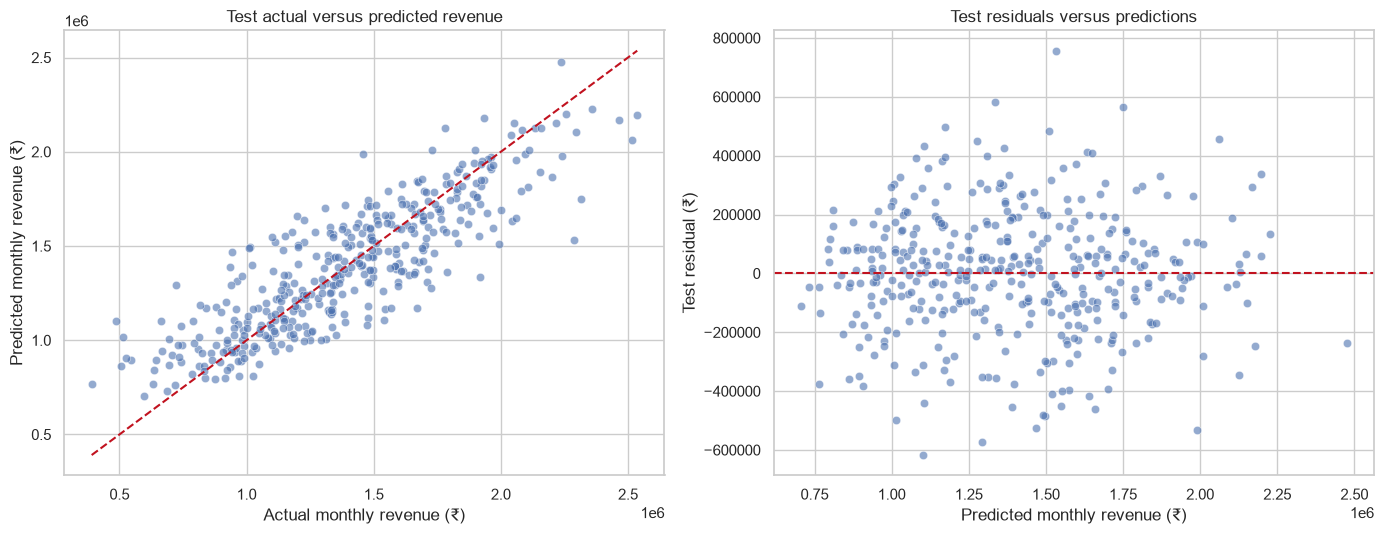

In [36]:
# Plot actual versus predicted revenue and test residuals.
test_residuals = y_test.to_numpy() - testing_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(x=y_test, y=testing_predictions, alpha=0.60, ax=axes[0])
prediction_limits = [
    min(y_test.min(), testing_predictions.min()),
    max(y_test.max(), testing_predictions.max()),
]
axes[0].plot(prediction_limits, prediction_limits, "--", color="#C1121F")
axes[0].set_title("Test actual versus predicted revenue")
axes[0].set_xlabel("Actual monthly revenue (₹)")
axes[0].set_ylabel("Predicted monthly revenue (₹)")

sns.scatterplot(x=testing_predictions, y=test_residuals, alpha=0.60, ax=axes[1])
axes[1].axhline(0, color="#C1121F", linestyle="--")
axes[1].set_title("Test residuals versus predictions")
axes[1].set_xlabel("Predicted monthly revenue (₹)")
axes[1].set_ylabel("Test residual (₹)")

plt.tight_layout()
plt.show()

## Final performance interpretation

The pipeline achieves training R² of approximately **0.753** and testing R² of **0.734**. RMSE is approximately **₹204,071** on training data and **₹208,217** on testing data. The small train–test gap and similar absolute errors indicate reasonable generalization rather than clear overfitting. The model leaves meaningful unexplained variation, so it is not implausibly deterministic; it also does not show the very low performance expected from severe underfitting.

# Step 9 — Coefficients and business interpretation

Feature names are extracted from the fitted preprocessing step and paired with the final linear-regression coefficients. Numerical coefficients correspond to a **one-standard-deviation increase** because numerical features were standardized. Categorical coefficients represent the expected revenue difference from the specified reference category, holding all other predictors constant.

In [37]:
# Extract transformed feature names and fitted linear coefficients.
transformed_feature_names = final_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()
final_coefficients = final_pipeline.named_steps["linear_regression"].coef_

coefficient_table = pd.DataFrame(
    {
        "Feature": transformed_feature_names,
        "Coefficient_INR": final_coefficients,
    }
)
coefficient_table["Absolute_Coefficient"] = coefficient_table["Coefficient_INR"].abs()
coefficient_table["Direction"] = np.where(
    coefficient_table["Coefficient_INR"].ge(0), "Positive", "Negative"
)
coefficient_table = coefficient_table.sort_values(
    "Absolute_Coefficient", ascending=False, ignore_index=True
)
display(coefficient_table)

,Feature,Coefficient_INR,Absolute_Coefficient,Direction
0,Target_Segment_High Value,"138,223.95","138,223.95",Positive
1,Ad_Spend,"125,576.67","125,576.67",Positive
2,Clicks,"115,815.61","115,815.61",Positive
3,Average_Order_Value,"106,093.58","106,093.58",Positive
4,Campaign_Channel_Display,"-96,917.24","96,917.24",Negative
5,Target_Segment_Price Sensitive,"-94,223.76","94,223.76",Negative
6,Conversion_Rate,"78,385.00","78,385.00",Positive
7,Target_Segment_Small Business,"71,230.91","71,230.91",Positive
8,Campaign_Channel_Social Media,"-64,105.33","64,105.33",Negative
9,Campaign_Duration_Days,"56,742.72","56,742.72",Positive


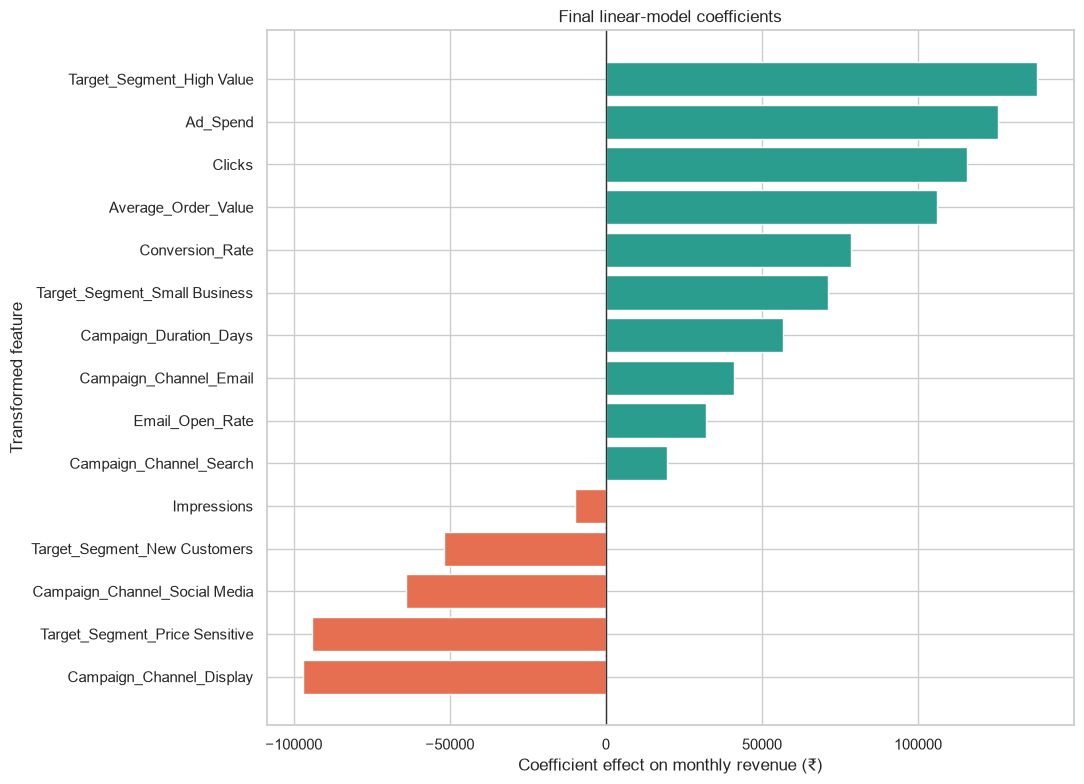

In [38]:
# Plot signed coefficients in descending absolute-value order.
plot_coefficients = coefficient_table.sort_values("Coefficient_INR")
coefficient_colors = np.where(
    plot_coefficients["Coefficient_INR"].ge(0), "#2A9D8F", "#E76F51"
)

plt.figure(figsize=(11, 8))
plt.barh(
    plot_coefficients["Feature"],
    plot_coefficients["Coefficient_INR"],
    color=coefficient_colors,
)
plt.axvline(0, color="#333333", linewidth=1)
plt.title("Final linear-model coefficients")
plt.xlabel("Coefficient effect on monthly revenue (₹)")
plt.ylabel("Transformed feature")
plt.tight_layout()
plt.show()

## Coefficient interpretation and managerial insights

The largest standardized numerical effects are positive for `Ad_Spend` (about ₹125,577 per training standard deviation), `Clicks` (₹115,816), `Average_Order_Value` (₹106,094), and `Conversion_Rate` (₹78,385), holding the other variables constant. `Impressions` has a small negative conditional coefficient (about −₹9,875) despite a positive marginal relationship; this is consistent with overlap among spend, impressions, and clicks and should not be interpreted as impressions causing revenue to fall.

With **Affiliate** as the channel reference, Display and Social Media have lower conditional revenue estimates, while Email and Search have higher estimates. With **Existing Customers** as the segment reference, High Value and Small Business are higher, while Price Sensitive and New Customers are lower, conditional on the numerical campaign metrics.

Practical insights for a marketing manager:

1. Budget, click volume, order value, and conversion performance are the strongest modelled revenue signals.
2. Reach alone is less informative after engagement and spending are controlled; impressions should be evaluated together with clicks and conversion efficiency.
3. Channel comparisons should use Affiliate as the reference and should control for campaign scale before judging performance.
4. High Value and Small Business campaigns show stronger conditional revenue potential than the Existing Customer reference group.
5. Forecasts should remain within the training ranges and should be accompanied by an error allowance of roughly the observed test RMSE.

These coefficients describe associations in an observational synthetic dataset and do **not** prove causation. Prediction uncertainty remains substantial, correlated funnel variables make isolated coefficient interpretation sensitive, and extrapolation beyond observed campaign ranges is unsafe.

# Step 10 — Save and verify the model

The entire fitted pipeline—including preprocessing and linear regression—is saved as `model.pkl`. Reloading and equality checks verify that deployment uses the same fitted transformation and prediction logic. A training-derived `feature_metadata.json` file records the raw input schema, category choices, and safe numeric ranges for the web application.

In [39]:
# Confirm fitted state, save the pipeline, reload it, and verify predictions.
from sklearn.utils.validation import check_is_fitted
import json

check_is_fitted(final_pipeline.named_steps["linear_regression"])

MODEL_PATH = Path("model.pkl")
METADATA_PATH = Path("feature_metadata.json")
joblib.dump(final_pipeline, MODEL_PATH)

try:
    reloaded_pipeline = joblib.load(MODEL_PATH)
    check_is_fitted(reloaded_pipeline.named_steps["linear_regression"])
except Exception as error:
    raise RuntimeError("The saved pipeline could not be reloaded as a fitted model.") from error

# Use an actual valid test-set row as the one-row raw prediction example.
example_input = X_test.loc[:, predictor_columns].iloc[[0]].copy()
original_example_prediction = final_pipeline.predict(example_input)

try:
    reloaded_example_prediction = reloaded_pipeline.predict(example_input)
except Exception as error:
    raise RuntimeError("The reloaded pipeline could not predict from the raw feature schema.") from error

predictions_match = np.allclose(
    original_example_prediction,
    reloaded_example_prediction,
    rtol=1e-12,
    atol=1e-8,
)
if not predictions_match:
    raise RuntimeError("Original and reloaded pipeline predictions do not match.")

display(example_input)
print("Original pipeline prediction (₹):", float(original_example_prediction[0]))
print("Reloaded pipeline prediction (₹):", float(reloaded_example_prediction[0]))
print("Predictions match:", predictions_match)

,Campaign_Channel,Target_Segment,Ad_Spend,Impressions,Clicks,Conversion_Rate,Average_Order_Value,Campaign_Duration_Days,Email_Open_Rate
1860,Search,Small Business,"396,717.03",1294716,41747,6.13,"5,013.96",84,25.46


Original pipeline prediction (₹): 2086385.2282649996
Reloaded pipeline prediction (₹): 2086385.2282649996
Predictions match: True


In [40]:
# Save and print the exact raw input contract for the web application.
integer_predictors = {"Impressions", "Clicks", "Campaign_Duration_Days"}
feature_metadata = {
    "identifier_excluded": identifier_column,
    "target_excluded": target_column,
    "feature_names": predictor_columns,
    "categorical_features": {
        column: {
            "values": sorted(X_train[column].astype(str).unique().tolist()),
            "dtype": "string",
        }
        for column in categorical_predictors
    },
    "numeric_features": {
        column: {
            "minimum": int(X_train[column].min()) if column in integer_predictors else float(X_train[column].min()),
            "maximum": int(X_train[column].max()) if column in integer_predictors else float(X_train[column].max()),
            "median": int(round(X_train[column].median())) if column in integer_predictors else float(X_train[column].median()),
            "dtype": "integer" if column in integer_predictors else "float",
        }
        for column in numerical_predictors
    },
}

with METADATA_PATH.open("w", encoding="utf-8") as metadata_file:
    json.dump(feature_metadata, metadata_file, indent=2)

print("Expected raw predictor names:")
print(feature_metadata["feature_names"])
print("\nAllowed categorical values:")
for column, information in feature_metadata["categorical_features"].items():
    print(f"- {column}: {information['values']}")
print("\nTraining-derived numeric ranges:")
for column, information in feature_metadata["numeric_features"].items():
    print(
        f"- {column}: {information['minimum']} to {information['maximum']} "
        f"({information['dtype']})"
    )
print("\nExcluded from user inputs:", identifier_column, "and", target_column)
print("Saved:", MODEL_PATH.resolve())
print("Saved:", METADATA_PATH.resolve())

Expected raw predictor names:
['Campaign_Channel', 'Target_Segment', 'Ad_Spend', 'Impressions', 'Clicks', 'Conversion_Rate', 'Average_Order_Value', 'Campaign_Duration_Days', 'Email_Open_Rate']

Allowed categorical values:
- Campaign_Channel: ['Affiliate', 'Display', 'Email', 'Search', 'Social Media']
- Target_Segment: ['Existing Customers', 'High Value', 'New Customers', 'Price Sensitive', 'Small Business']

Training-derived numeric ranges:
- Ad_Spend: 16038.29 to 492697.19 (float)
- Impressions: 22973 to 2000000 (integer)
- Clicks: 425 to 128297 (integer)
- Conversion_Rate: 0.5 to 13.55 (float)
- Average_Order_Value: 801.04 to 10000.0 (float)
- Campaign_Duration_Days: 7 to 90 (integer)
- Email_Open_Rate: 5.82 to 65.0 (float)

Excluded from user inputs: Campaign_ID and Monthly_Revenue_Generated
Saved: C:\Users\upama\OneDrive\Desktop\AISPP assignment\model.pkl
Saved: C:\Users\upama\OneDrive\Desktop\AISPP assignment\feature_metadata.json


# Step 11 — Streamlit web application

The accompanying `app.py` provides the complete **Digital Marketing Monthly Revenue Predictor** interface. It loads the saved pipeline once with `st.cache_resource`, never retrains it, validates all inputs, predicts only when the user selects the button, and explains prediction uncertainty.

Run the application from this project directory with:

```bash
streamlit run app.py
```

In [41]:
# Verify that the complete Streamlit source file exists and has valid Python syntax.
import ast

APP_PATH = Path("app.py")
if not APP_PATH.exists():
    raise FileNotFoundError("app.py was not found in the project directory.")

app_source = APP_PATH.read_text(encoding="utf-8")
try:
    ast.parse(app_source, filename=str(APP_PATH))
except SyntaxError as error:
    raise RuntimeError("app.py contains invalid Python syntax.") from error

print("Streamlit application syntax check passed.")
print("Application path:", APP_PATH.resolve())
print("The app loads model.pkl and feature_metadata.json; it does not train a model.")

Streamlit application syntax check passed.
Application path: C:\Users\upama\OneDrive\Desktop\AISPP assignment\app.py
The app loads model.pkl and feature_metadata.json; it does not train a model.


## Final limitations

The application returns a model estimate rather than guaranteed revenue. The synthetic data omits factors such as seasonality, creative quality, competition, attribution error, macroeconomic conditions, and profit margins. The model should not be used for causal claims, and predictions outside the saved training ranges should be avoided.